In [1]:
import pandas as pd
import re
import struct
import matplotlib.pyplot as plt
import numpy as np
import sys
import os

from scipy.signal import find_peaks
from scipy.stats import binned_statistic
import matplotlib.colors as mcolors

current_dir = '/home/marian/CIGAR_ANALYSIS/CIGAR/notebooks'

# Build the absolute path to ../functions
functions_path = os.path.abspath(os.path.join(current_dir, '../functions'))

# Add it to sys.path
sys.path.append(functions_path)

import parse_data 
import cigar as cig


from tqdm import tqdm



/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
colors = ['royalblue', 'crimson', 'black', 'green', 'darkorange', 'brown', 'coral', 'indigo', 'magenta']


##  Data reading

In [3]:
# run         = 'Run125'
run         = 'Run119'
# run         = 'Run22'
run_dir     = f"/home/marian/CIGAR_ANALYSIS/CIGAR/data/{run}"

new_board = True

nchannels       = 10
nevents_per_wvf = 500

if new_board:
    samples_per_waveform = 1124
    # samples_per_waveform = 2000
else:
    samples_per_waveform = 752

event_header_bytes = 28
# event_header_bytes = 3036
# time_window = (1.8e-6 < time)  & (time < 3e-6)

# sample_binning = 1
sample_binning = 8e-9

nfiles = 10


fixBaselines_noAmp = {'CH1': -369
                      ,'CH2': -410
                      ,'CH3': -350
                      ,'CH4': -408
                      }

In [4]:
# CHECK WAVEFORMS' SIZES
print_headers = False
# --- Example usage ---
if __name__ == "__main__":

    for file in os.listdir(run_dir)[:5]:
        if file.endswith(".bin"):
            file_path = os.path.join(run_dir, file)
        path = file_path

        waveforms, headers = parse_data.load_waveforms_until_eof(
            path,
            channels=nchannels,
            samples_per_waveform=samples_per_waveform,
            dtype="<f4",
            event_header_bytes=event_header_bytes,  # set to 0 if no per-event header
        )

        print("Waveforms shape:", waveforms.shape)  # (num_events, 4, 500)
        if print_headers:
            if headers is not None:
                print("Headers shape:", headers.shape)   # (num_events, 7) for 28 bytes
                print("First header:", headers[0])


Waveforms shape: (500, 10, 1124)
Waveforms shape: (500, 10, 1124)
Waveforms shape: (500, 10, 1124)
Waveforms shape: (500, 10, 1124)
Waveforms shape: (500, 10, 1124)


In [5]:

# Initialize an empty list to store DataFrames
dataframes = []

# Loop through each folder and read all CSV files
for i, file in enumerate(tqdm(os.listdir(run_dir)[:nfiles],desc="Reading .bin files", unit="file")):
    if file.endswith(".bin"):
        file_path = os.path.join(run_dir, file)
        # print(file_path)
        df = parse_data.parse_wf_from_binary(file_path, 
                                             channels = nchannels, 
                                             n_events = nevents_per_wvf,
                                             file_idx = i,
                                             event_header_bytes = event_header_bytes,
                                             sample_binning = sample_binning
                                             )  
        dataframes.append(df)

Reading .bin files: 100%|██████████| 10/10 [00:34<00:00,  3.40s/file]


In [6]:
# Merge all DataFrames into one
merged_df = pd.concat(dataframes, ignore_index=True)

In [7]:
df = merged_df
df.tail()

,TIME,CH1,CH2,CH3,CH4,CH5,CH6,CH7,CH8,CH9,CH10,event,event_time,file_idx
5619995,0.000009,1.048798,2.760570,-507.557587,412.471619,328.831177,353.723389,-466.644287,375.596802,-544.741882,416.973907,4999,803293525961,9
5619996,0.000009,1.048798,2.883262,-501.990112,412.839050,332.390747,353.907043,-468.361694,375.289978,-549.171204,417.158142,4999,803293525961,9
5619997,0.000009,1.048798,3.374030,-493.791840,412.900299,329.813141,354.090698,-470.876465,375.289978,-554.154114,417.096710,4999,803293525961,9
5619998,0.000009,0.802022,3.005954,-482.840454,413.451508,323.369080,354.151917,-477.746094,375.289978,-552.431641,416.973907,4999,803293525961,9
5619999,0.000009,1.110492,3.312684,-478.680145,414.370148,304.466492,353.845825,-488.479889,375.228638,-555.938171,417.342346,4999,803293525961,9


##  Data selection

In [8]:
# Filter for a specific event (change index as needed)
event_list  = df['event'].unique()
nevents     = len(event_list)
print(f'Unfiltered df nevents = {nevents}')

Unfiltered df nevents = 5000


In [9]:
if nchannels == 5:
    A_chs    = ['CH2', 'CH3', 'CH4', 'CH5'] # Amp
    noA_chs  = [] # noAmp

elif nchannels == 9:
    A_chs    = ['CH3', 'CH5', 'CH7', 'CH9'] # Amp
    noA_chs  = ['CH2', 'CH4', 'CH6', 'CH8'] # noAmp

elif nchannels == 10:
    A_chs    = ['CH4', 'CH6', 'CH8', 'CH10'] # Amp
    noA_chs  = ['CH3', 'CH5', 'CH7', 'CH9'] # noAmp

if new_board:
    Amp_channels    = noA_chs # Amp
    noAmp_channels  = A_chs # noAmp
else:
    Amp_channels    = A_chs # Amp
    noAmp_channels  = noA_chs # noAmp

all_channels    = noAmp_channels + Amp_channels


##  Data filtering

In [10]:
# # function to count number of peaks above threshold for one waveform
# def count_high_peaks(group, threshold=1000):
#     peak_count = 0
#     for ch in Amp_channels:
#         peaks, _ = find_peaks(group[f'{ch}'].values, height=threshold)
#         peak_count += len(peaks)
#     return peak_count

# # group by event (or event_time if that's more appropriate)
# peak_counts = df.groupby("event").apply(count_high_peaks)

# # keep only events with <= 5 peaks above 2000
# valid_events = peak_counts[peak_counts <= 4].index

threshold = -800

# find min value per event (across all channels)
min_values = (
            df.groupby("event")
              .head(300)  # Take first 300 samples per event
              .groupby("event")[Amp_channels]
              .min()
              .min(axis=1)
)

# keep only events whose minimum value is above threshold
valid_events = min_values[min_values > threshold].index

# filter the original dataframe
filtered_df = df[df["event"].isin(valid_events)]

# update the number of valid events
event_list  = filtered_df['event'].unique()
nevents     = len(event_list)
print(f'Filtered df nevents = {nevents}')

Filtered df nevents = 3316


##  Amplified channels Baseline re-calculation

In [11]:
# DEFINITION OF THE BASELINE WINDOW WITH HERE
if new_board:
    pretrigger      = 90
else:
    pretrigger      = 200


In [12]:
time = filtered_df['TIME'].values
t_matrix = time.reshape(nevents, -1)

In [13]:
if new_board:
    time_window = (0.8e-6 < time)  & (time < 2e-6)
else:
    time_window = (1.8e-6 < time)  & (time < 3e-6)


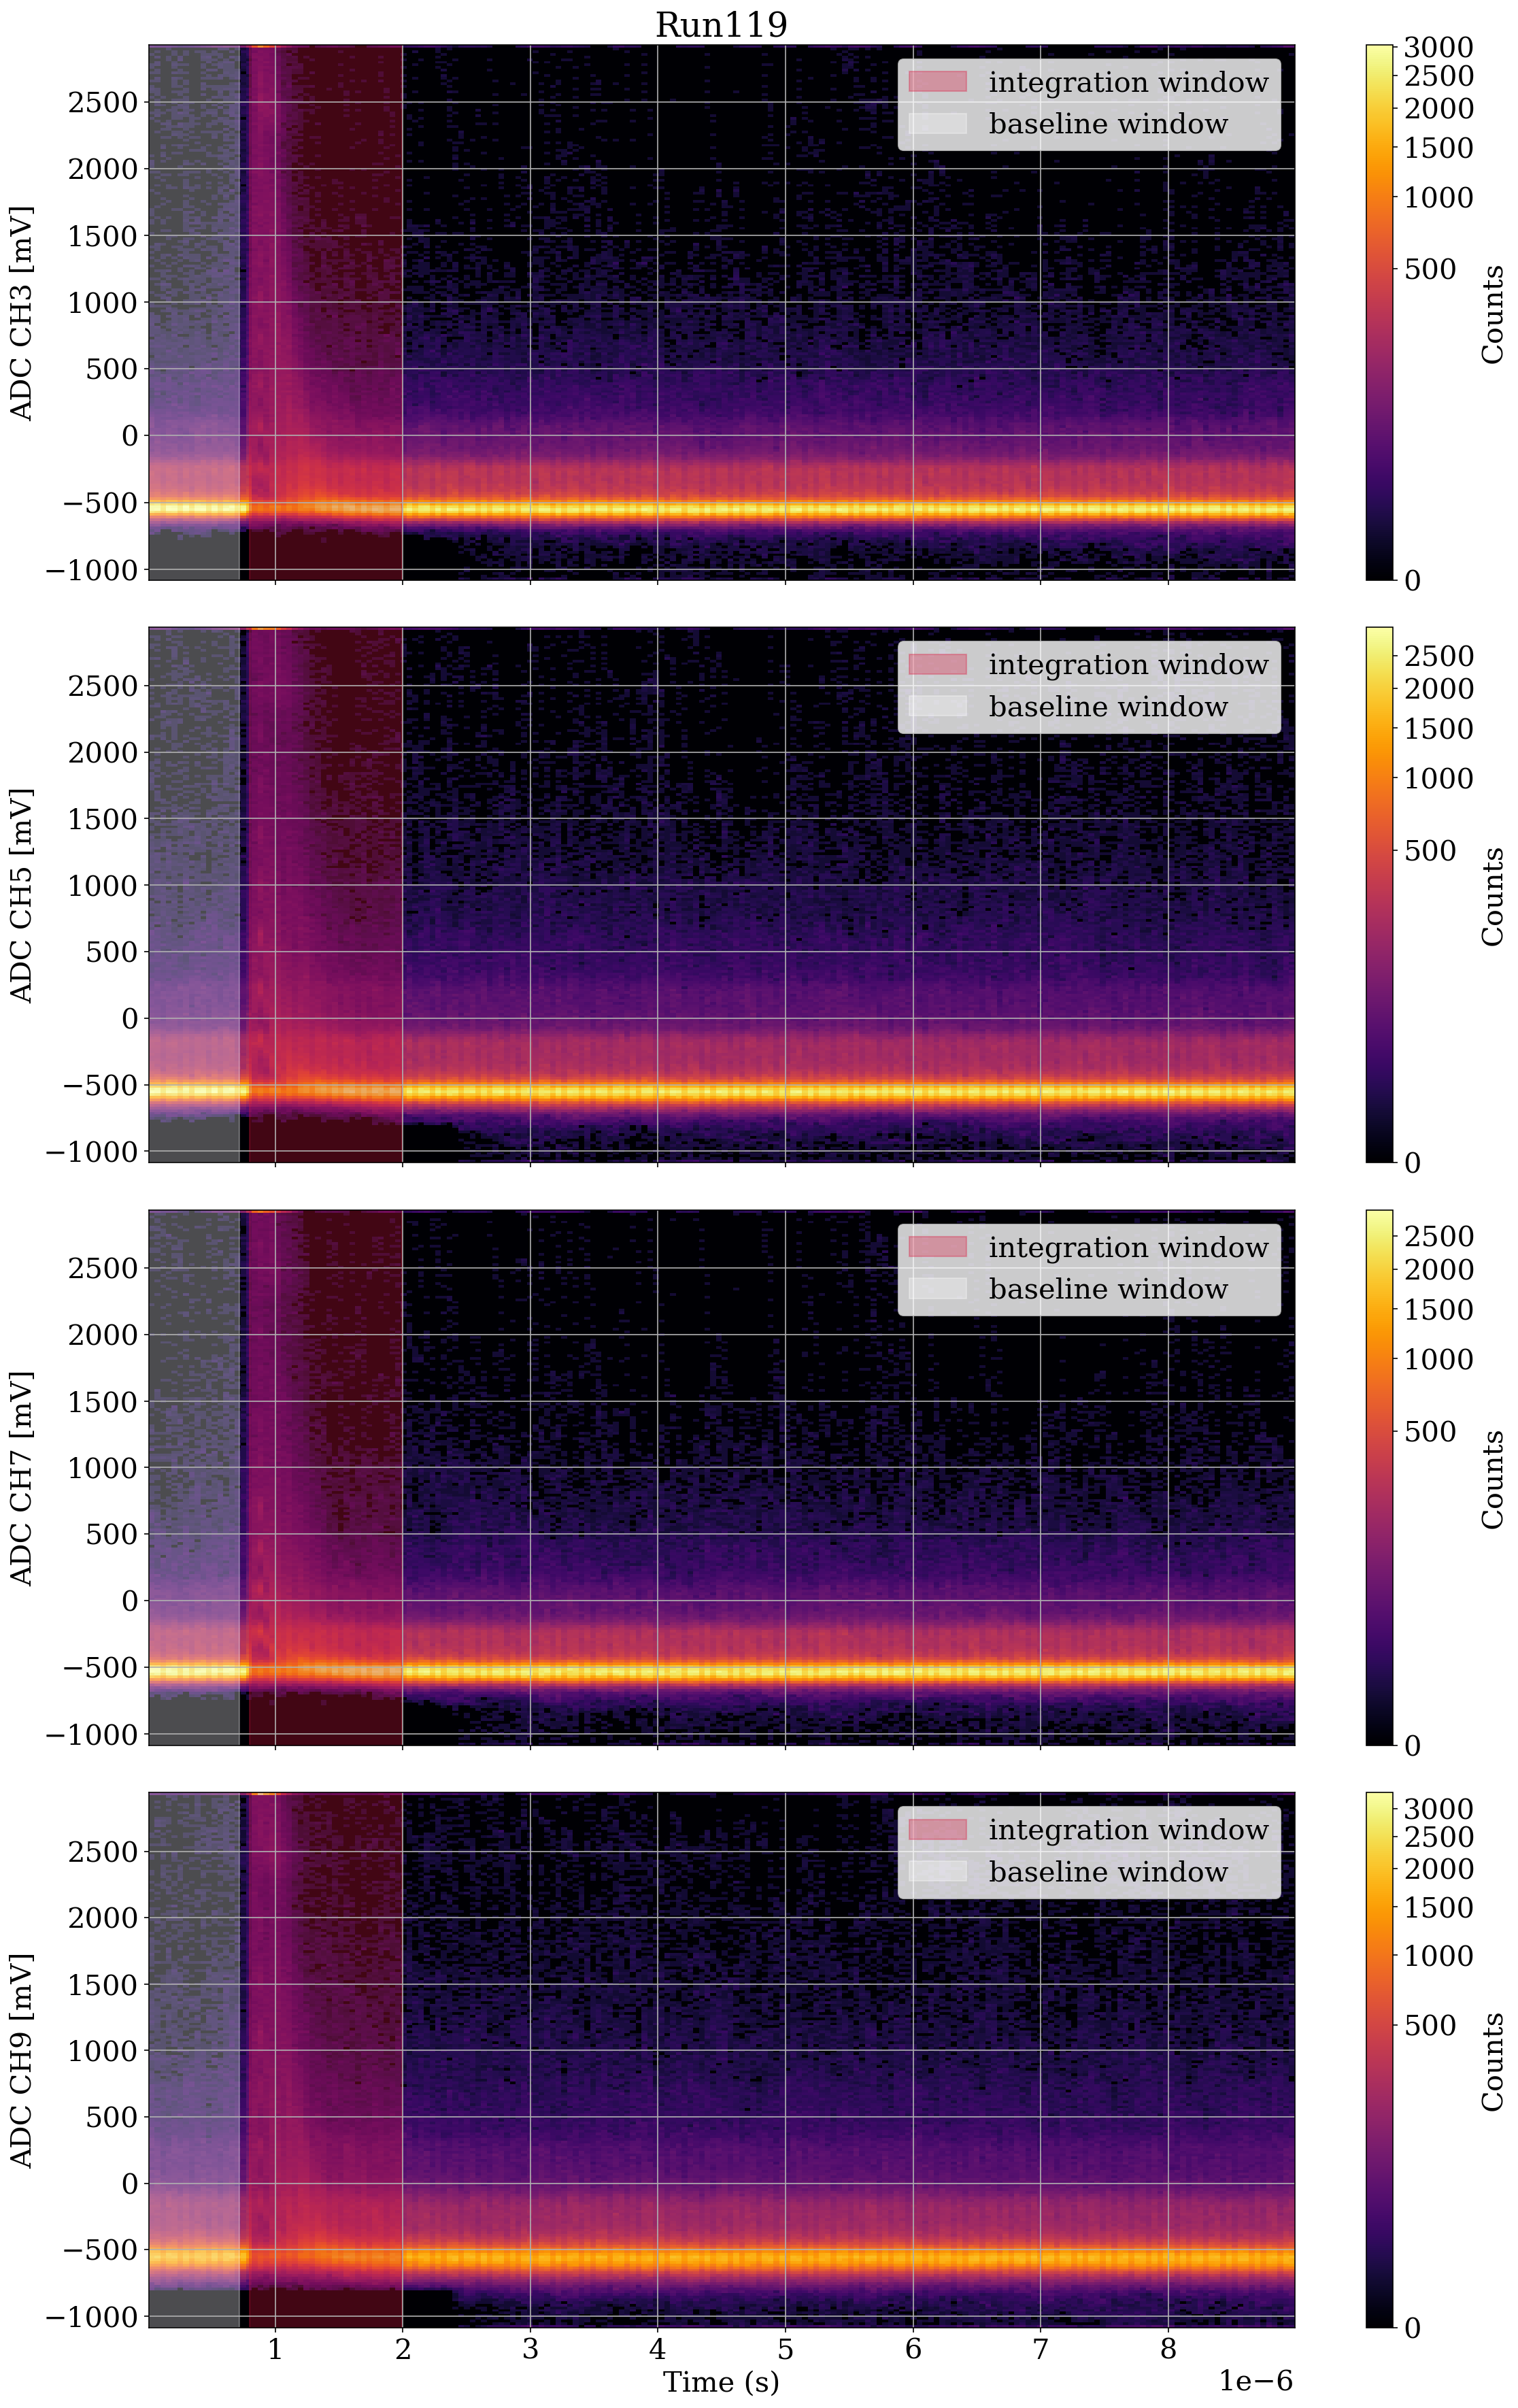

In [14]:
# Create subplots: 2 rows, 1 column

if len(Amp_channels) > 1:
    fig, axs = plt.subplots(len(Amp_channels), 1, figsize=(16, len(Amp_channels)*6), dpi=150, sharex=True)
else:
    fig, ax = plt.subplots(1, 1, figsize=(16, 6), dpi=150, sharex=True)

if len(Amp_channels) > 1:
    axs[0].set_title(f'{run}')
else:
    ax.set_title(f'{run}')


# Plot CHs
for i in range(len(Amp_channels)):

    if len(Amp_channels) > 1:
        ax = axs[i]

    voltage  = filtered_df[f'{Amp_channels[i]}'].values
    v_matrix = voltage.reshape(nevents, -1)
    
    # voltage_matrix = np.array([...]) # shape (nevents, nsamples)
    # hb = ax.hist2d(t_matrix.flatten(), v_matrix_corrected.flatten(), bins=[200, 200], 
    #                cmap='inferno', norm=mcolors.PowerNorm(gamma=0.5))
    hb = ax.hist2d(time, v_matrix.flatten(), bins=[200, 200], 
                   cmap='inferno', norm=mcolors.PowerNorm(gamma=0.3))

    fig.colorbar(hb[3], ax=ax, label="Counts")

    ax.fill_between(t_matrix[0][time_window.reshape(nevents, -1)[0]], 
                    v_matrix.min(), v_matrix.max(), 
                    color = colors[1], alpha = 0.3, label = 'integration window')
    
    ax.fill_between(time[:pretrigger], v_matrix.min(), v_matrix.max(), 
                    color = 'white', alpha = 0.3, label = 'baseline window')

    ax.set_ylabel(f'ADC {Amp_channels[i]} [mV]')
    ax.grid(True)
    ax.legend()

if len(Amp_channels) > 1:
    axs[-1].set_xlabel('Time (s)')
else:
    ax.set_xlabel('Time (s)')

# plt.xlim(-2e-7,40e-7)

# Improve layout
plt.tight_layout()
plt.show()

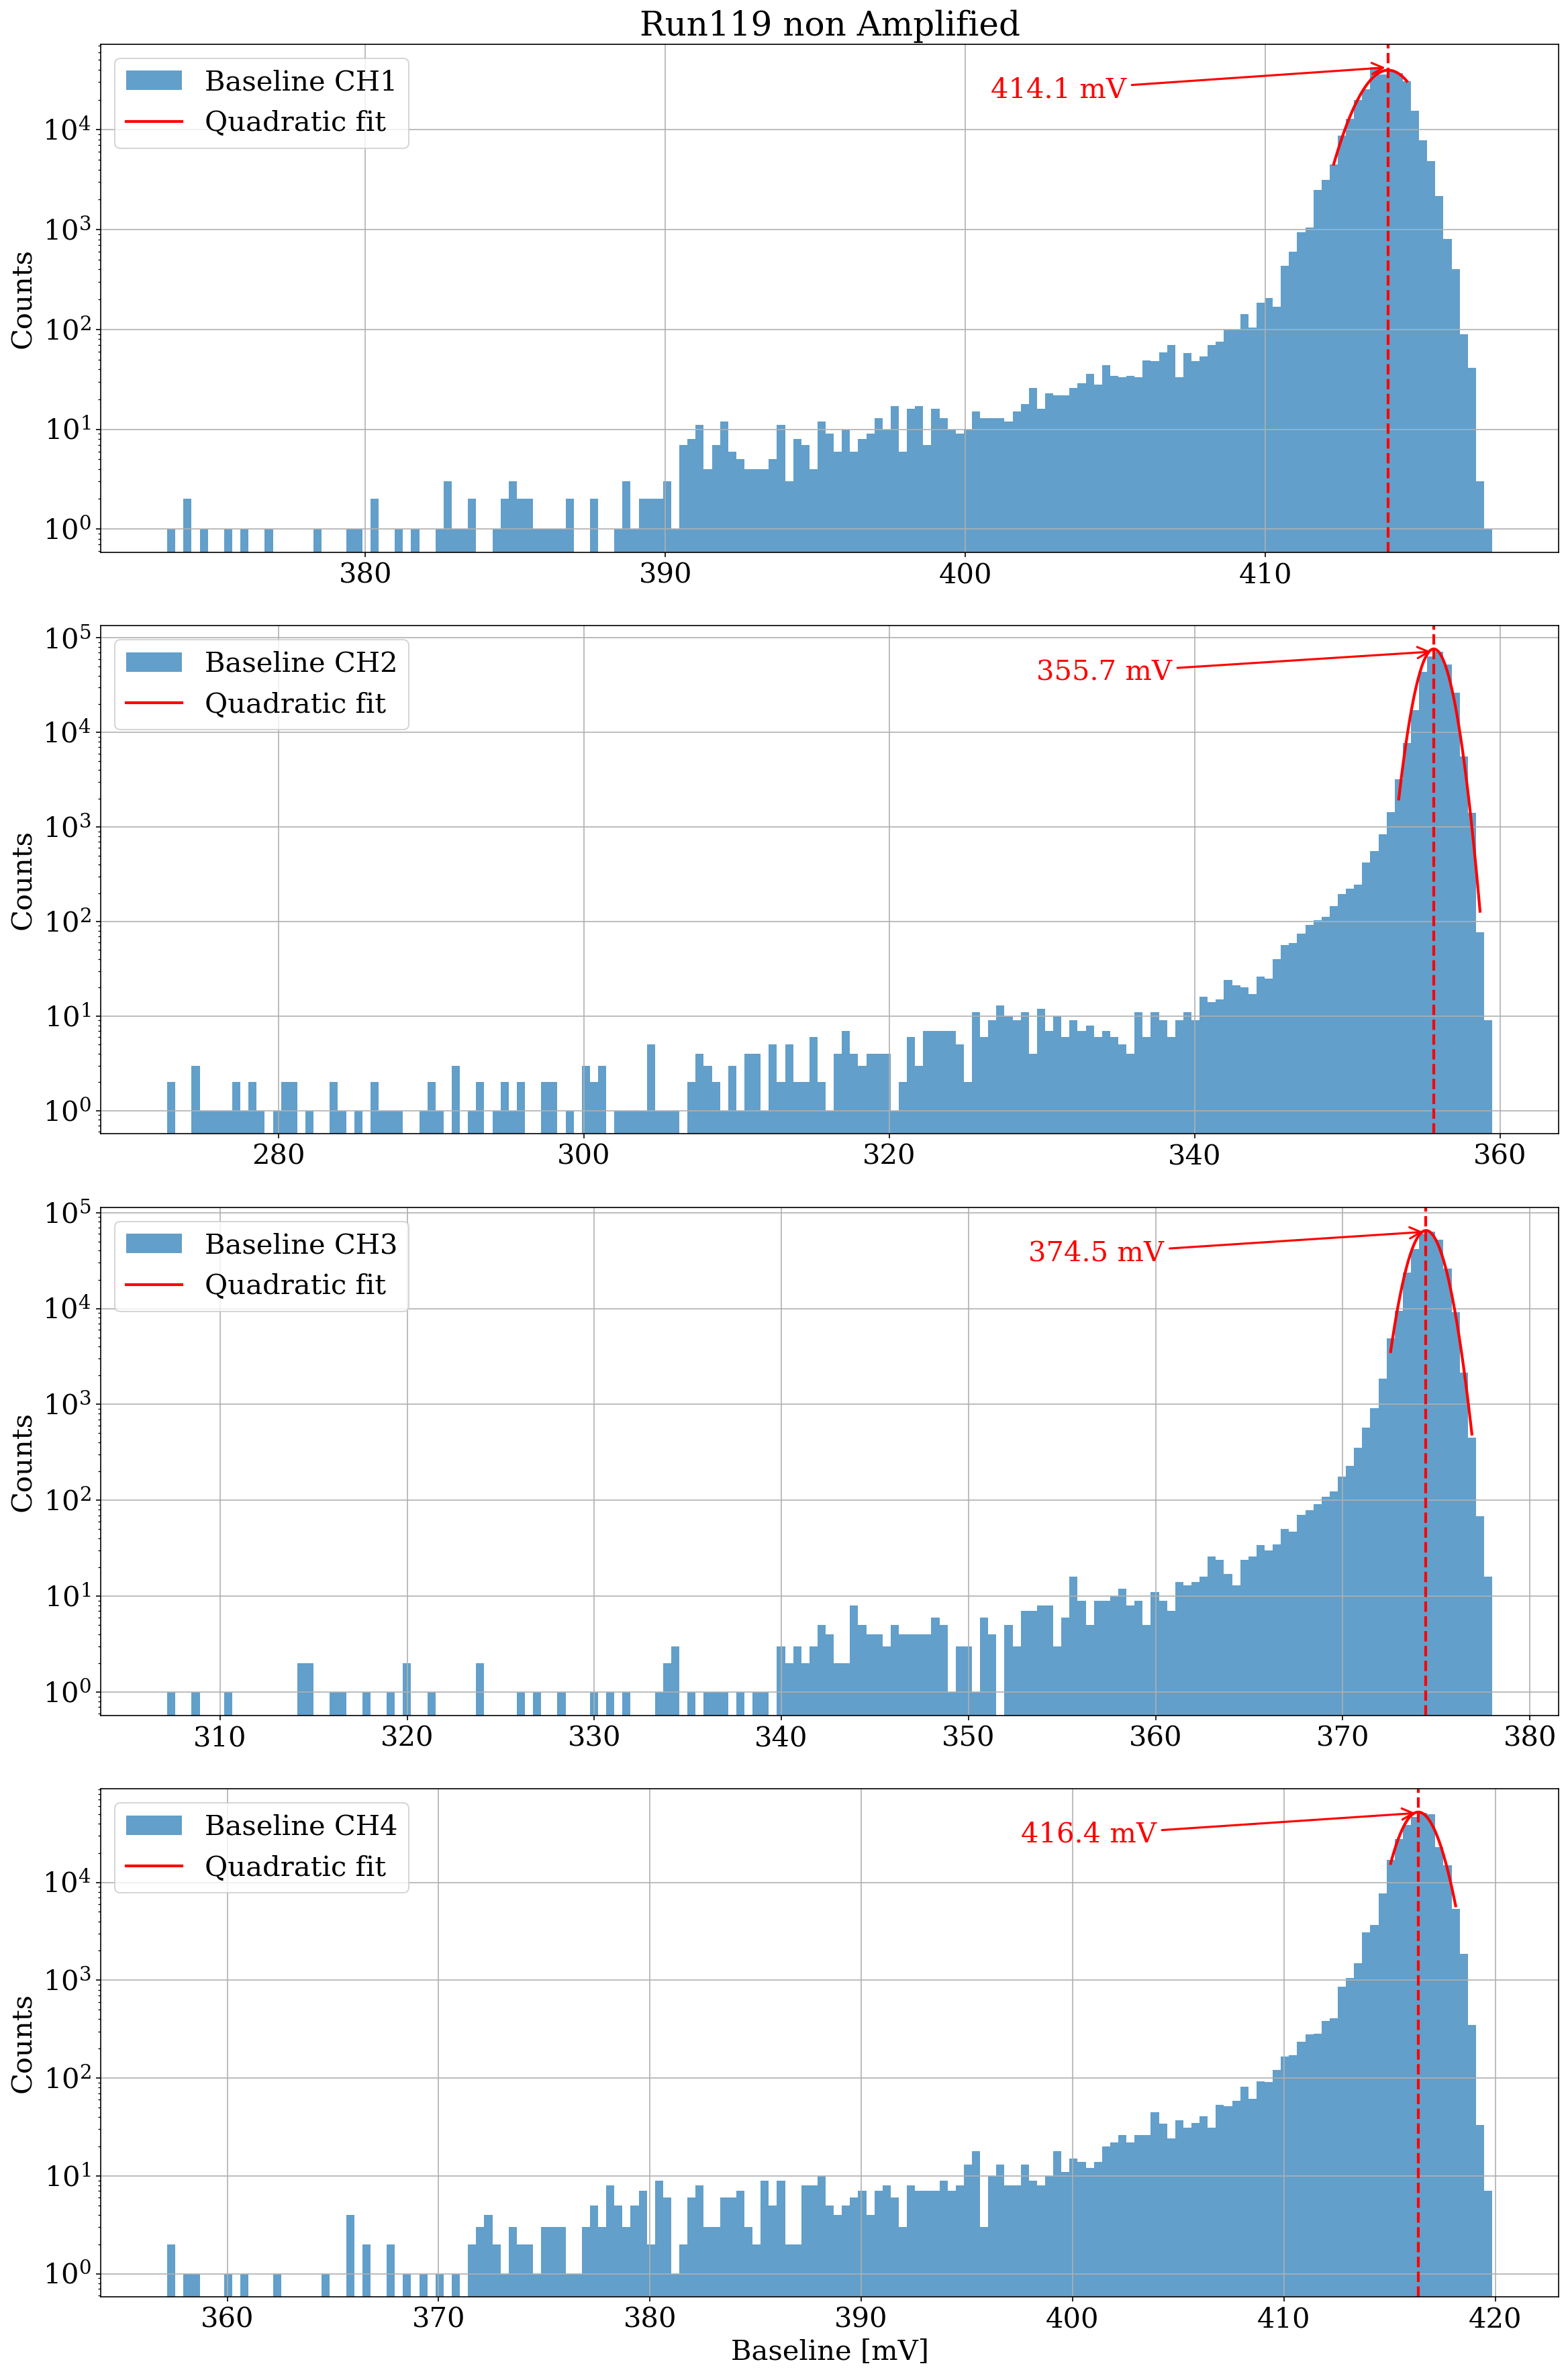

In [15]:
# Create subplots: 2 rows, 1 column

if len(noAmp_channels) > 1:
    fig, axs = plt.subplots(len(noAmp_channels), 1, figsize=(16, len(noAmp_channels)*6), dpi=150, sharex=False)
else:
    fig, ax = plt.subplots(1, 1, figsize=(16, 6), dpi=150, sharex=False)

if len(noAmp_channels) > 1:
    axs[0].set_title(f'{run} non Amplified')
else:
    ax.set_title(f'{run} non Amplified')


# Plot CHs
for i in range(len(noAmp_channels)):

    if len(noAmp_channels) > 1:
        ax = axs[i]

    voltage  = filtered_df[f'{noAmp_channels[i]}'].values
    v_matrix = voltage.reshape(nevents, -1)

    baselines = (v_matrix[:, :pretrigger]).flatten()
    
    
    events, bins, image = ax.hist(baselines
                                ,bins = int(0.3*np.sqrt(len(baselines))) 
                                ,density = False
                                ,alpha = 0.7
                                ,label = f'Baseline CH{i+1}'
                                )
    
    bin_centers = 0.5 * (bins[1:] + bins[:-1])    
    mode_initial = bin_centers[np.argmax(events)]
    
    # Define fitting region around the mode
    bin_width = bins[1] - bins[0]
    window = 5 * bin_width  # e.g., ±10 bins worth around the mode
    
    # Select data in the fitting region
    fit_mask = (bin_centers >= mode_initial - window) & (bin_centers <= mode_initial + window)
    x_fit = bin_centers[fit_mask]
    y_fit = np.log(events[fit_mask] + 1)  # log scale, add 1 to avoid log(0)
    
    try:
        # Fit quadratic polynomial (degree 2)
        coeffs = np.polyfit(x_fit, y_fit, 2)
        a, b, c = coeffs
        
        # Peak of quadratic is at x = -b/(2a)
        fitted_peak = -b / (2 * a)
        
        # Plot the fit
        x_fine = np.linspace(x_fit.min(), x_fit.max(), 200)
        y_fine = np.polyval(coeffs, x_fine)
        ax.plot(x_fine, np.exp(y_fine) - 1, '-r', lw=2, label='Quadratic fit')
        
        # fixBaselines_noAmp[f'CH{i+1}'] = int(fitted_peak)
        fixBaselines_noAmp[f'CH{i+1}'] = fitted_peak
        peak_value = fitted_peak
        
    except:
        print(f"Fit failed for CH{i+1}, using mode instead")
        # fixBaselines_noAmp[f'CH{i+1}'] = int(mode_initial)
        fixBaselines_noAmp[f'CH{i+1}'] = mode_initial
        peak_value = mode_initial

    # Vertical dashed line at mode
    ax.axvline(peak_value, color='red', linestyle='--', lw=2)
    # Arrow + label
    ymax = events.max()
    ax.annotate(
        f"{peak_value:.1f} mV",
        xy=(peak_value, ymax),
        xytext=(peak_value - 0.3*(bins[-1] - bins[0]), 0.5*ymax),
        arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
        color='red',
        fontsize=20,
        ha='left'
    )

    ax.set_ylabel(f'Counts')
    ax.grid(True)
    ax.legend()
    ax.set_yscale('log')

if len(noAmp_channels) > 1:
    axs[-1].set_xlabel('Baseline [mV]')
else:
    ax.set_xlabel('Baseline [mV]')

# plt.xlim(-2e-7,40e-7)

# Improve layout
plt.tight_layout()
plt.show()

In [16]:
fixBaselines_noAmp

{'CH1': 414.0886783358635,
 'CH2': 355.6502803397511,
 'CH3': 374.4513379655729,
 'CH4': 416.36134059977405}

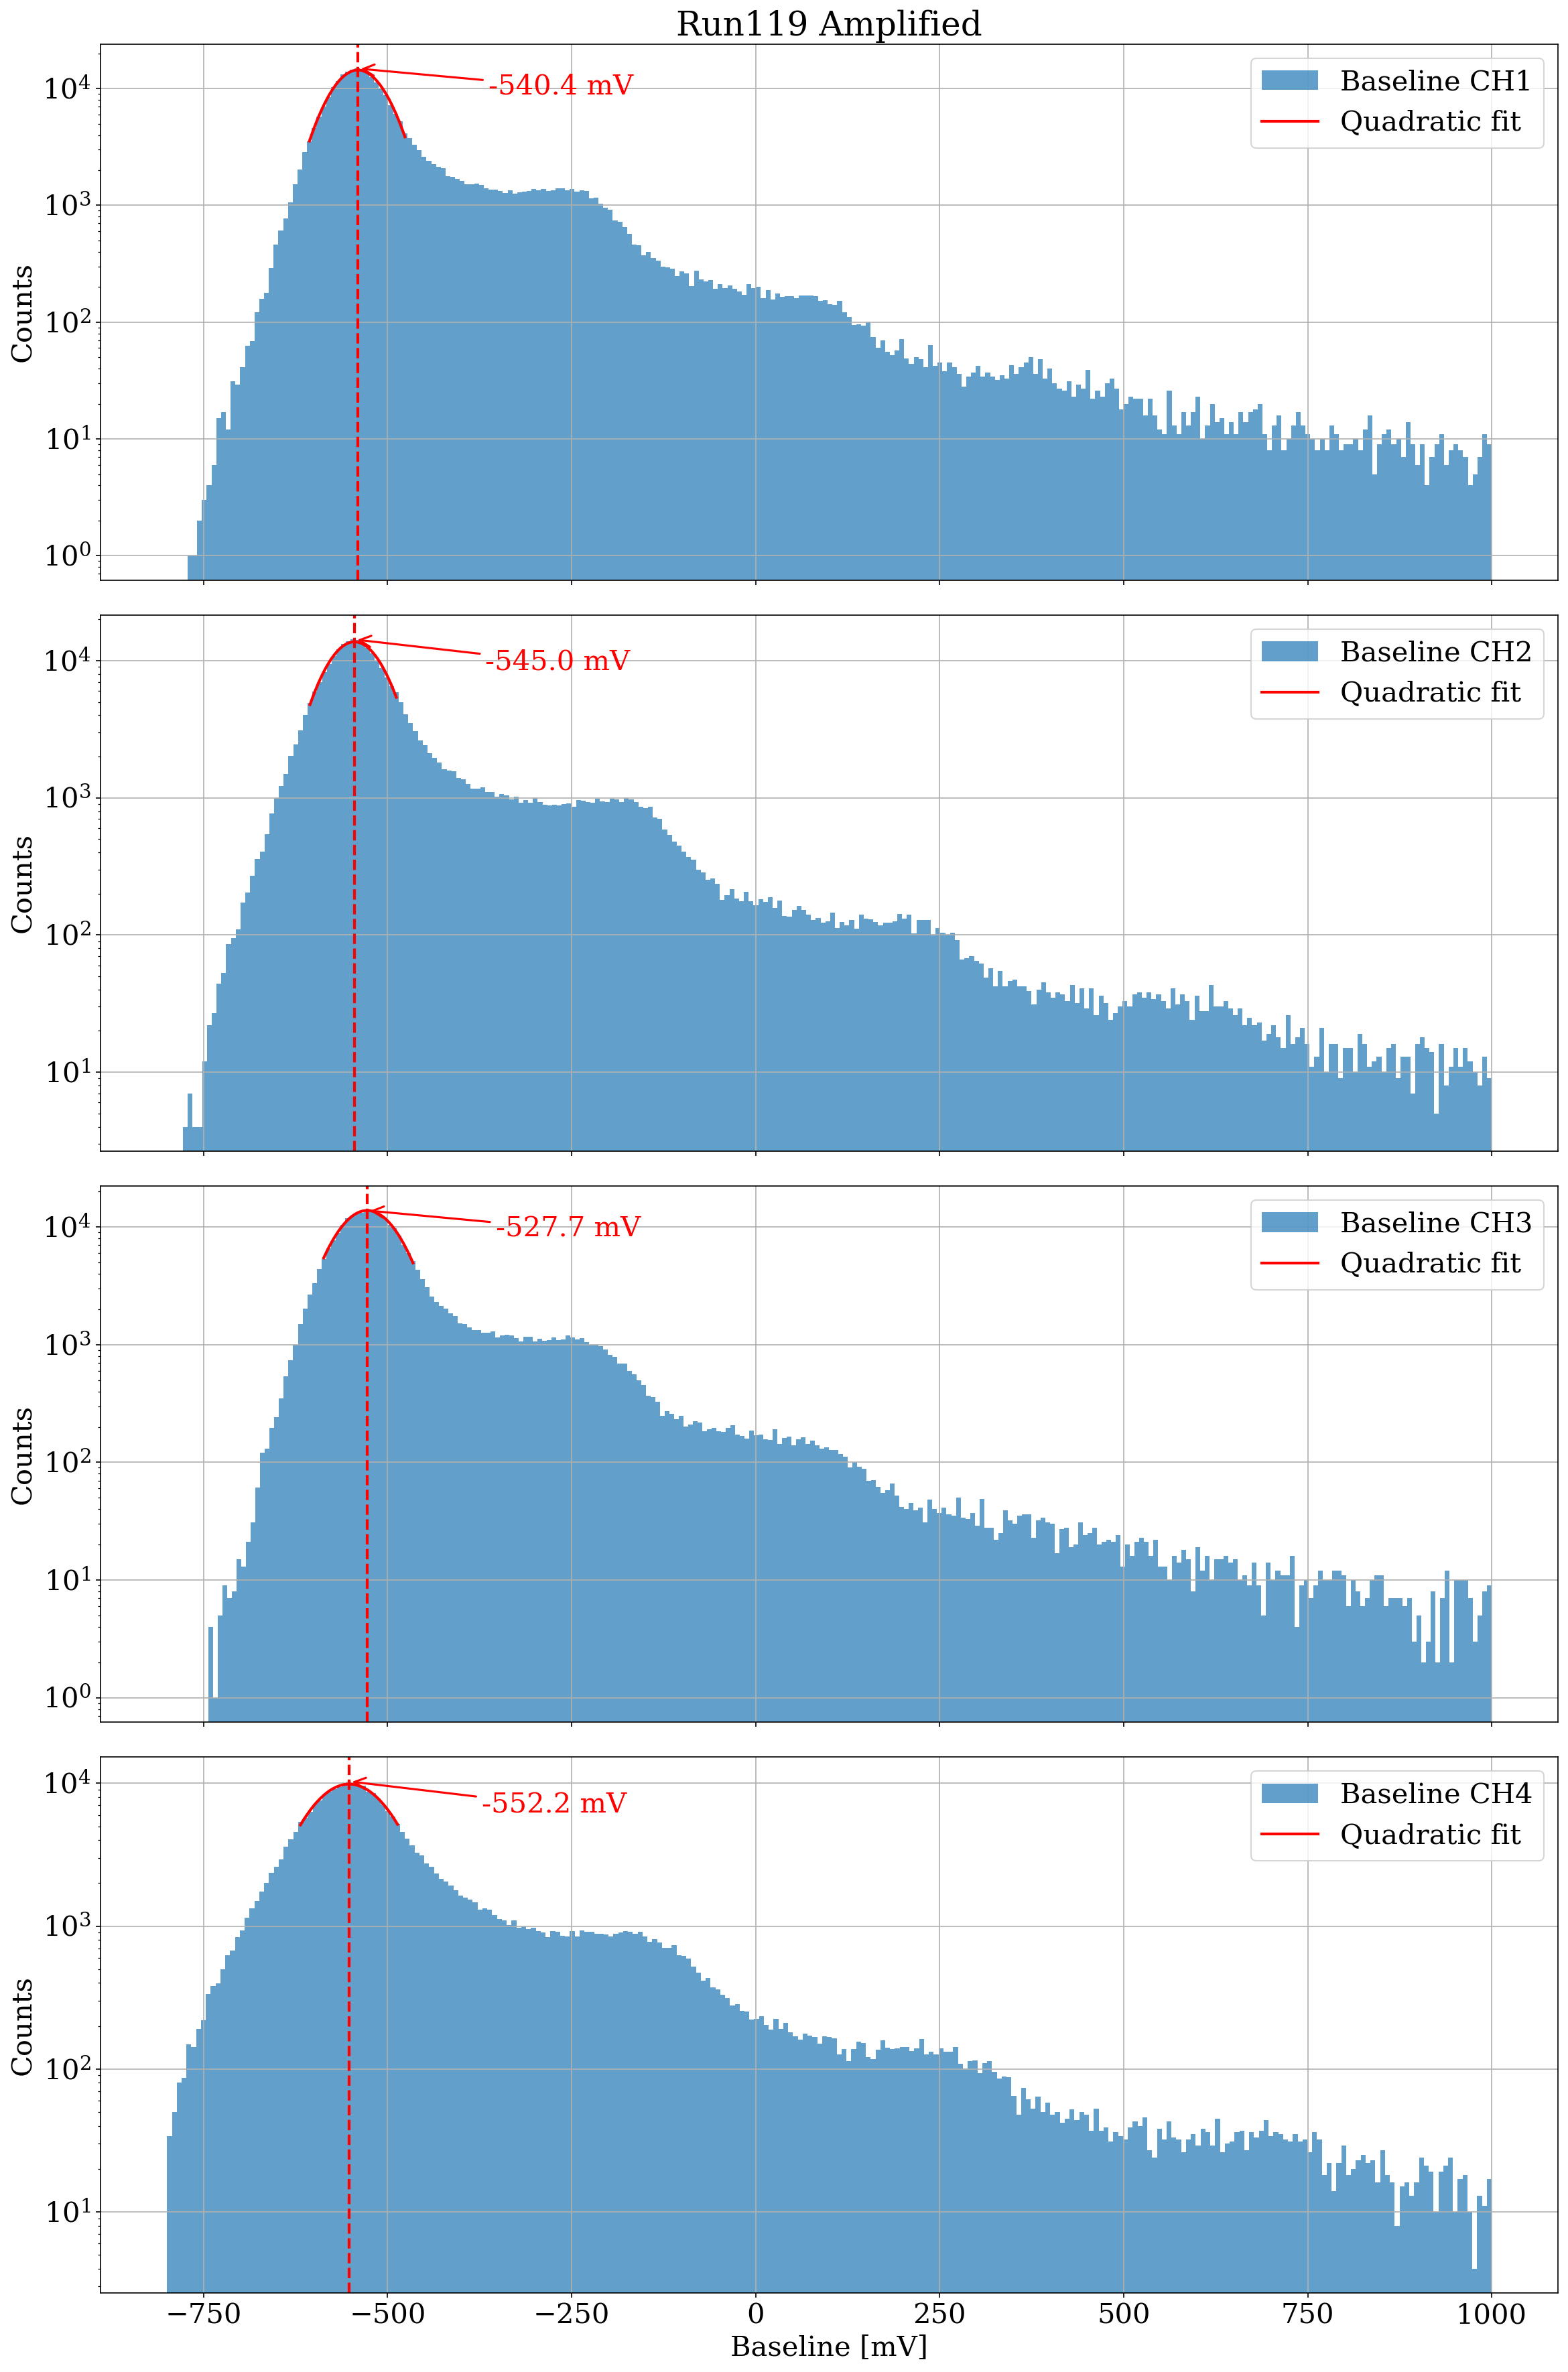

In [17]:
# Create subplots: 2 rows, 1 column

if len(Amp_channels) > 1:
    fig, axs = plt.subplots(len(Amp_channels), 1, figsize=(16, len(Amp_channels)*6), dpi=150, sharex=True)
else:
    fig, ax = plt.subplots(1, 1, figsize=(16, 6), dpi=150, sharex=True)

if len(Amp_channels) > 1:
    axs[0].set_title(f'{run} Amplified')
else:
    ax.set_title(f'{run} Amplified')

fixBaselines_Amp = {}
# Plot CHs
for i in range(len(Amp_channels)):

    if len(Amp_channels) > 1:
        ax = axs[i]

    voltage  = filtered_df[f'{Amp_channels[i]}'].values
    v_matrix = voltage.reshape(nevents, -1)

    baselines = (v_matrix[:, :pretrigger]).flatten()
    
    
    events, bins, image = ax.hist(baselines
                                ,bins = int(0.5*np.sqrt(len(baselines))) 
                                ,range = (baselines.min(), 1000)
                                ,density = False
                                ,alpha = 0.7
                                ,label = f'Baseline CH{i+1}'
                                )
    
    bin_centers = 0.5 * (bins[1:] + bins[:-1])
    
    mode_initial = bin_centers[np.argmax(events)]
    
    # Define fitting region around the mode
    bin_width = bins[1] - bins[0]
    window = 10 * bin_width  # e.g., ±10 bins worth around the mode
    
    # Select data in the fitting region
    fit_mask = (bin_centers >= mode_initial - window) & (bin_centers <= mode_initial + window)
    x_fit = bin_centers[fit_mask]
    y_fit = np.log(events[fit_mask] + 1)  # log scale, add 1 to avoid log(0)
    
    try:
        # Fit quadratic polynomial (degree 2)
        coeffs = np.polyfit(x_fit, y_fit, 2)
        a, b, c = coeffs
        
        # Peak of quadratic is at x = -b/(2a) (first derivative = 0)
        fitted_peak = -b / (2 * a)
        
        # Plot the fit
        x_fine = np.linspace(x_fit.min(), x_fit.max(), 200)
        y_fine = np.polyval(coeffs, x_fine)
        ax.plot(x_fine, np.exp(y_fine) - 1, '-r', lw=2, label='Quadratic fit')
        
        # fixBaselines_Amp[f'CH{i+1}'] = int(fitted_peak)
        fixBaselines_Amp[f'CH{i+1}'] = fitted_peak
        peak_value = fitted_peak
        
    except:
        print(f"Fit failed for CH{i+1}, using mode instead")
        # fixBaselines_Amp[f'CH{i+1}'] = int(mode_initial)
        fixBaselines_Amp[f'CH{i+1}'] = mode_initial
        peak_value = mode_initial

    # Vertical dashed line at mode
    ax.axvline(peak_value, color='red', linestyle='--', lw=2)
    # Arrow + label
    ymax = events.max()
    ax.annotate(
        f"{peak_value:.1f} mV",
        xy=(peak_value, ymax),
        xytext=(peak_value + 0.1*(bins[-1] - bins[0]), 0.6*ymax),
        arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
        color='red',
        fontsize=20,
        ha='left'
    )

    ax.set_ylabel(f'Counts')
    ax.grid(True)
    ax.legend()
    ax.set_yscale('log')

if len(Amp_channels) > 1:
    axs[-1].set_xlabel('Baseline [mV]')
else:
    ax.set_xlabel('Baseline [mV]')

# plt.xlim(-2e-7,40e-7)

# Improve layout
plt.tight_layout()
plt.show()

In [18]:
fixBaselines_Amp

{'CH1': -540.3552050132012,
 'CH2': -544.9969098043179,
 'CH3': -527.6904669246537,
 'CH4': -552.2256884486482}

In [19]:
# amp_offset = 600
# fixBaselines_Amp = {'CH1': -571
#                     ,'CH2': -610
#                     ,'CH3': -586
#                     ,'CH4': -581
#                     }

##  Example waveforms: non-amplified vs amplified

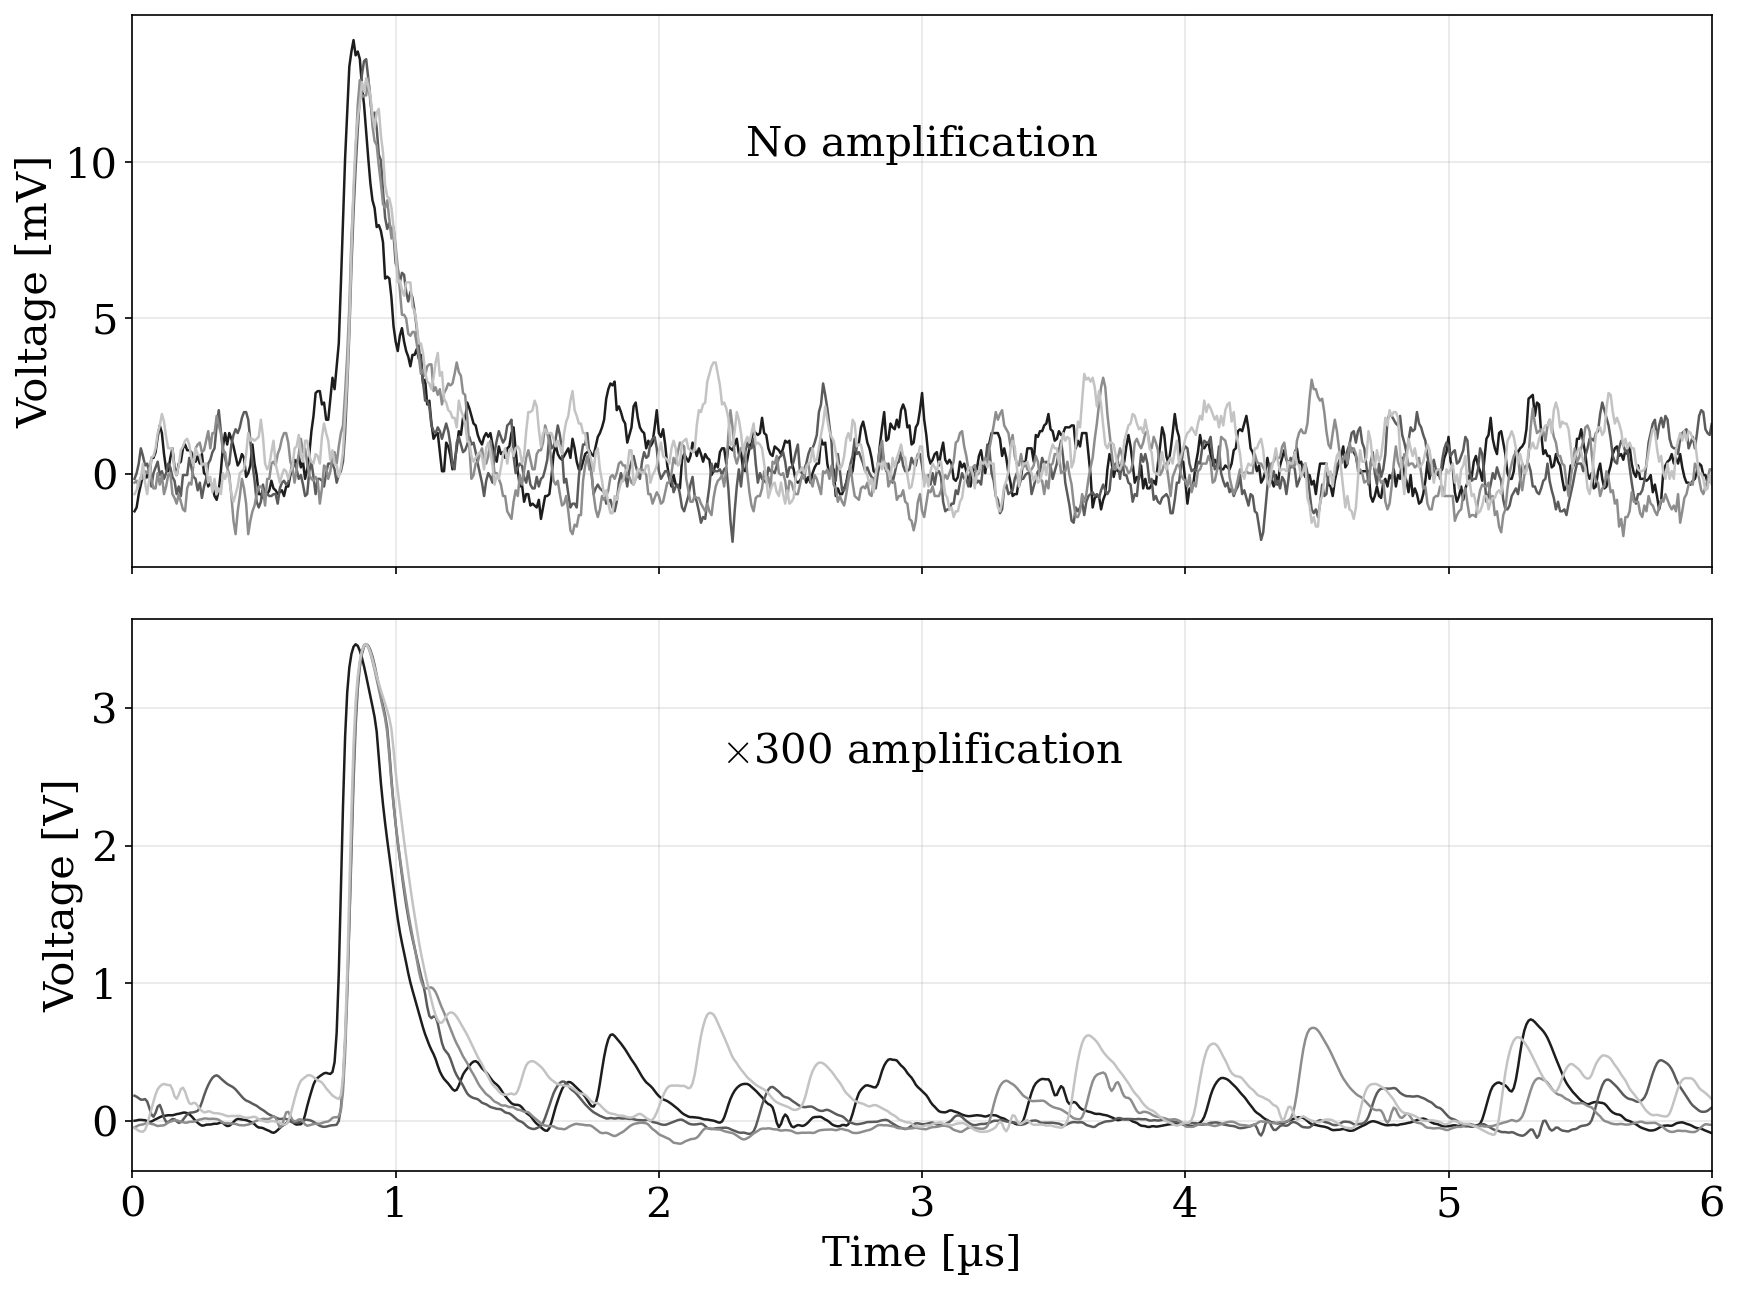

In [20]:
# Example waveforms overlaying a few events, baseline-corrected,
# showing the same pulses on the non-amplified and amplified channels

n_events_to_plot = 4
ch_idx  = 0   # which Amp/noAmp channel pair to show (CH{ch_idx+1})

noamp_ch = noAmp_channels[ch_idx]
amp_ch   = Amp_channels[ch_idx]

time_us = t_matrix[0] * 1e6

v_noamp_full = -filtered_df[noamp_ch].values.reshape(nevents, -1) + fixBaselines_noAmp[f'CH{ch_idx+1}']
v_amp_full   = (filtered_df[amp_ch].values.reshape(nevents, -1) - fixBaselines_Amp[f'CH{ch_idx+1}']) / 1000.0  # V

# pick events whose dominant pulse falls inside the integration window,
# with a clear (but non-saturated) amplitude
window_bool    = time_window.reshape(nevents, -1)[0]
peak_in_window = v_amp_full[:, window_bool].max(axis=1)
peak_overall   = v_amp_full.max(axis=1)

clean       = np.isclose(peak_in_window, peak_overall)
good_events = np.where(clean)[0]
amps        = peak_in_window[good_events]
order       = good_events[np.argsort(-amps)]
amps_sorted = peak_in_window[order]
sel         = order[(amps_sorted > np.percentile(amps, 40)) & (amps_sorted < np.percentile(amps, 95))]
event_indices = sel[:n_events_to_plot]

grays = plt.cm.Greys(np.linspace(0.9, 0.35, len(event_indices)))

fig, (ax_noamp, ax_amp) = plt.subplots(2, 1, figsize=(12, 9), dpi=150, sharex=True)

t_lo, t_hi = time_us[window_bool].min(), time_us[window_bool].max()

for k, evt in enumerate(event_indices):
    ax_noamp.plot(time_us, v_noamp_full[evt], color=grays[k], lw=1.2)
    ax_amp.plot(time_us, v_amp_full[evt], color=grays[k], lw=1.2)

# ax_noamp.axvspan(t_lo, t_hi, color='grey', alpha=0.2, zorder=0)
# ax_noamp.axvline(t_lo, color='k', ls='--', lw=1)
# ax_noamp.axvline(t_hi, color='k', ls='--', lw=1)
ax_noamp.text(0.5, 0.8, 'No amplification', transform=ax_noamp.transAxes, ha='center', va='top')
ax_noamp.set_ylabel('Voltage [mV]')
ax_noamp.grid(alpha=0.3)
ax_noamp.set_xlim(0, 6)

ax_amp.text(0.5, 0.8, r'$\times$300 amplification', transform=ax_amp.transAxes, ha='center', va='top')
ax_amp.set_ylabel('Voltage [V]')
ax_amp.set_xlabel('Time [µs]')
ax_amp.grid(alpha=0.3)

plt.tight_layout()
plt.show()

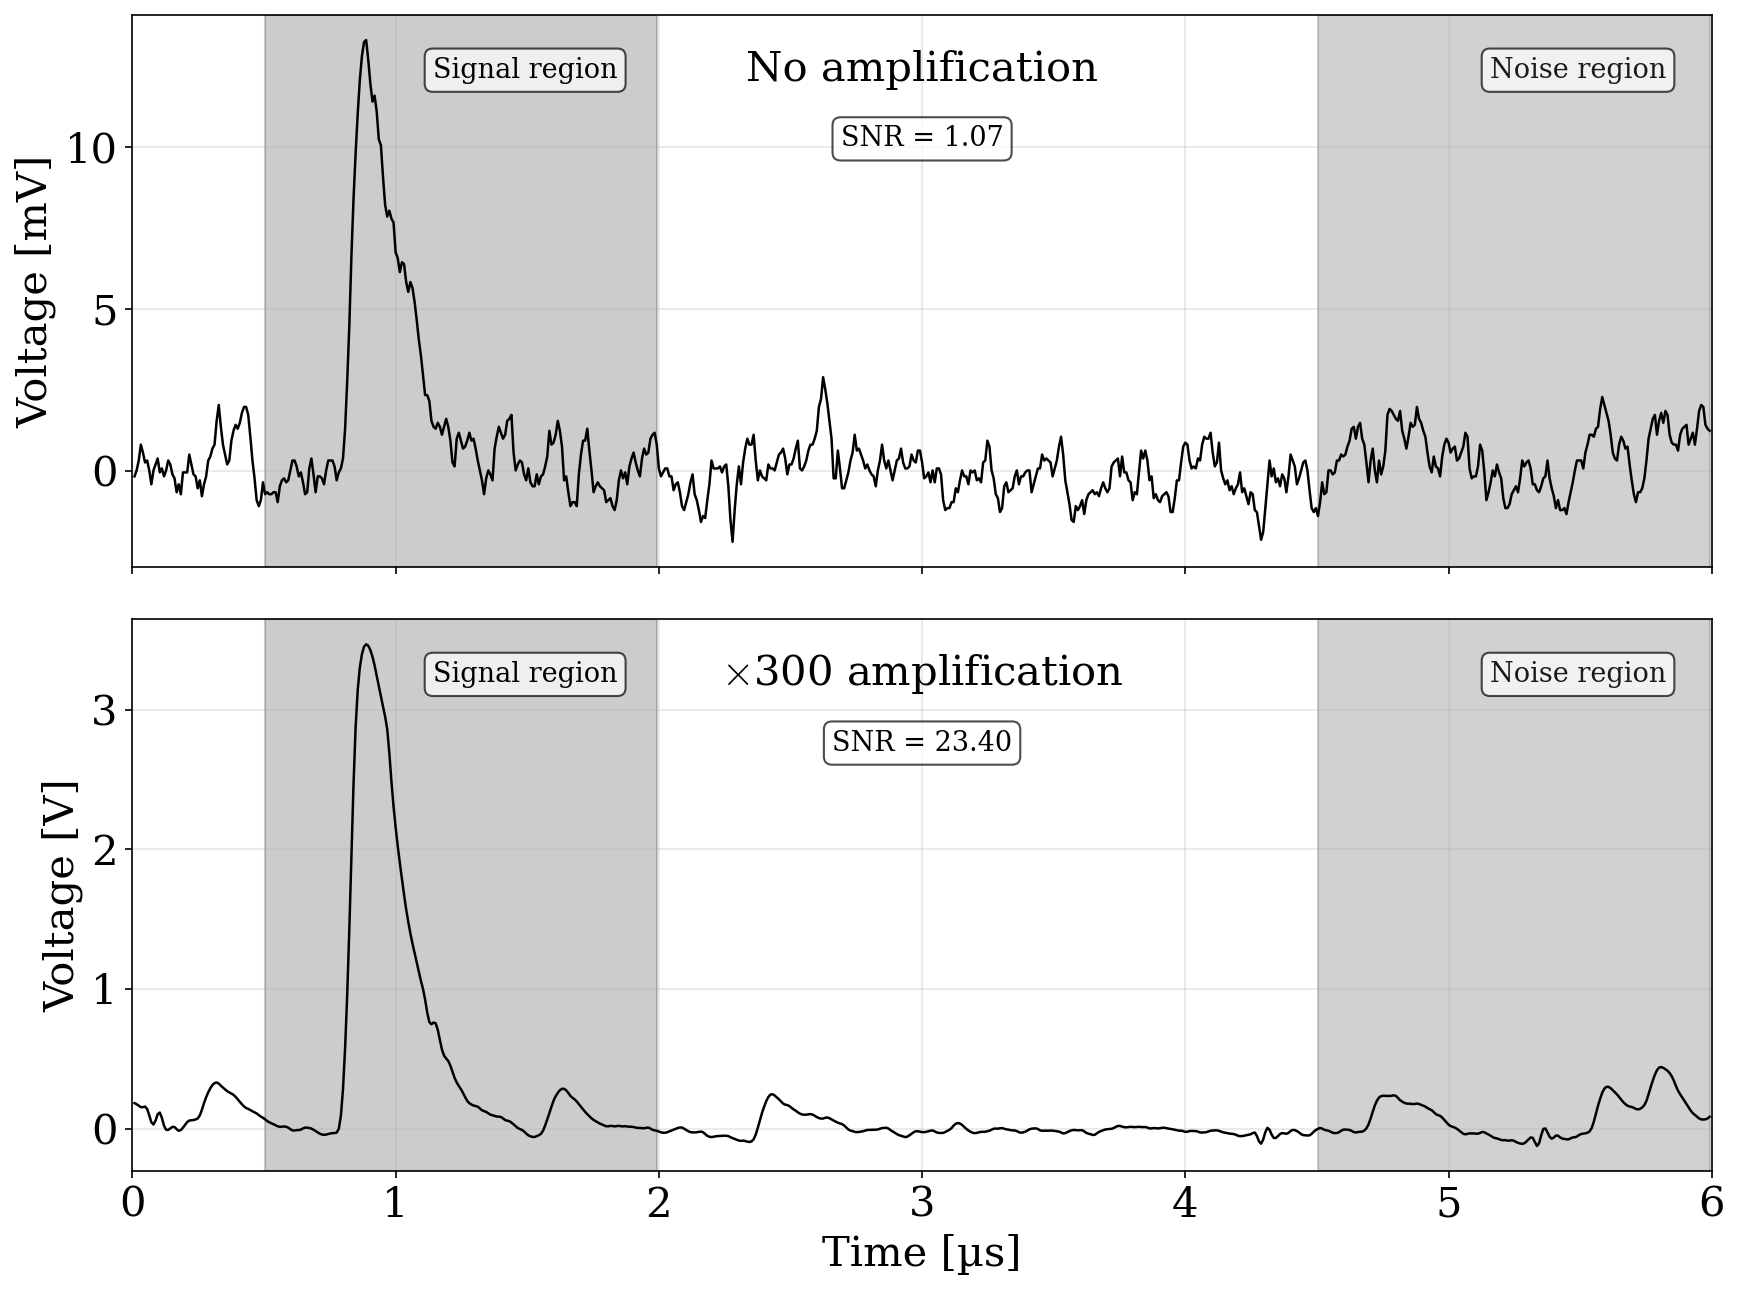

In [82]:
# Same single-event, baseline-corrected traces as the previous cell, but now
# integrated in two equal-width windows: a "signal" window running from the
# end of the pretrigger baseline up to 2us, and a same-width "noise" window
# taken from the tail of the waveform. SNR = S / sqrt(S + 2*N)
#
# NOTE ON UNITS: SNR = S/sqrt(S+2N) is NOT scale-invariant - scaling every
# voltage by k scales S and N by k, but only scales sqrt(S+2N) by sqrt(k),
# so SNR itself picks up a leftover sqrt(k) factor. That means computing it
# once from a millivolt-scale trace and once from a volt-scale trace (as the
# non-amp/amp channels naturally are here) makes the two SNR numbers
# incomparable for reasons that have nothing to do with actual signal
# quality. So: display each trace in its natural unit (mV for non-amp, V for
# amp), but compute the SNR itself with both channels rescaled to a common
# unit (mV), so the numbers are comparable.

ch_idx  = 0   # which Amp/noAmp channel pair to show (CH{ch_idx+1})

noamp_ch = noAmp_channels[ch_idx]
amp_ch   = Amp_channels[ch_idx]

time_us         = t_matrix[0] * 1e6
v_noamp_full    = -filtered_df[noamp_ch].values.reshape(nevents, -1) + fixBaselines_noAmp[f'CH{ch_idx+1}']  # mV, for display
v_amp_full      = (filtered_df[amp_ch].values.reshape(nevents, -1) - fixBaselines_Amp[f'CH{ch_idx+1}']) / 1000.0  # V, for display

waveform_mask = time_us < 6

time_us         = time_us[waveform_mask]
v_noamp_full    = v_noamp_full[:, waveform_mask]
v_amp_full      = v_amp_full[:, waveform_mask]

# signal window: end of the pretrigger baseline -> 2us
t_signal_start = .5 # [us]
t_signal_end   = 2 # [us]

signal_mask = (time_us >= t_signal_start) & (time_us < t_signal_end)
# noise window: same width, taken from the tail of the waveform
window_width = signal_mask.sum()

# pick one clean, non-saturated event (same selection logic as the previous cell)
peak_in_window = v_amp_full[:, signal_mask].max(axis=1)
peak_overall   = v_amp_full.max(axis=1)

clean       = np.isclose(peak_in_window, peak_overall)
good_events = np.where(clean)[0]
amps        = peak_in_window[good_events]
order       = good_events[np.argsort(-amps)]
amps_sorted = peak_in_window[order]
sel         = order[(amps_sorted > np.percentile(amps, 40)) & (amps_sorted < np.percentile(amps, 95))]
evt         = sel[0]

fig, (ax_noamp, ax_amp) = plt.subplots(2, 1, figsize=(12, 9), dpi=150, sharex=True)

for ax, v_full, unit_scale, label in [(ax_noamp, v_noamp_full, 1,     'No amplification'),
                                      (ax_amp,   v_amp_full,   1e3,   r'$\times$300 amplification')]:

    ax.plot(time_us, v_full[evt], color='black', lw=1.2)

    signal_lo, signal_hi = time_us[signal_mask][0], time_us[signal_mask][-1]
    noise_lo, noise_hi   = time_us[-window_width], time_us[-1]

    ax.axvspan(signal_lo, signal_hi, color=colors[0], alpha=0.2)
    ax.axvspan(noise_lo, noise_hi, color=colors[1], alpha=0.2)

    region_box = dict(boxstyle='round', fc='white', alpha=0.7)
    ax.text(signal_hi - .5, 0.9, 'Signal region',
            transform=ax.get_xaxis_transform(), ha='center', va='center',
            fontsize=13, color=colors[0], bbox=region_box)
    ax.text(noise_hi - .5, 0.9, 'Noise region',
            transform=ax.get_xaxis_transform(), ha='center', va='center',
            fontsize=13, color=colors[1], bbox=region_box)

    # SNR computed in mV (unit_scale) for both channels, so the numbers are comparable
    integration_total   = np.trapz(v_full[evt][signal_mask]*unit_scale, x=time_us[signal_mask])
    integration_dark    = np.trapz(v_full[evt][-window_width:]*unit_scale, x=time_us[-window_width:])

    signal              = integration_total - integration_dark
    variation_noise     = integration_total + integration_dark

    snr = signal / np.sqrt(variation_noise)

    ax.text(0.5, 0.9, label, transform=ax.transAxes, ha='center', va='center')
    ax.text(0.5, 0.8, f'SNR = {snr:.2f}', transform=ax.transAxes,
            ha='center', va='top', fontsize=13,
            bbox=dict(boxstyle='round', fc='white', alpha=0.7))

    ax.grid(alpha=0.3)

ax_noamp.set_ylabel('Voltage [mV]')
ax_amp.set_ylabel('Voltage [V]')
ax_amp.set_xlabel('Time [µs]')
ax_amp.set_xlim(0, 6)

plt.tight_layout()
plt.show()

In [49]:
waveform_mask.sum()

749

In [51]:
len(waveform_mask)

1124

In [55]:
np.shape(v_noamp_full[:, waveform_mask])

(3316, 749)

In [50]:
np.shape(v_noamp_full)

(3316, 1124)

##  Amplification

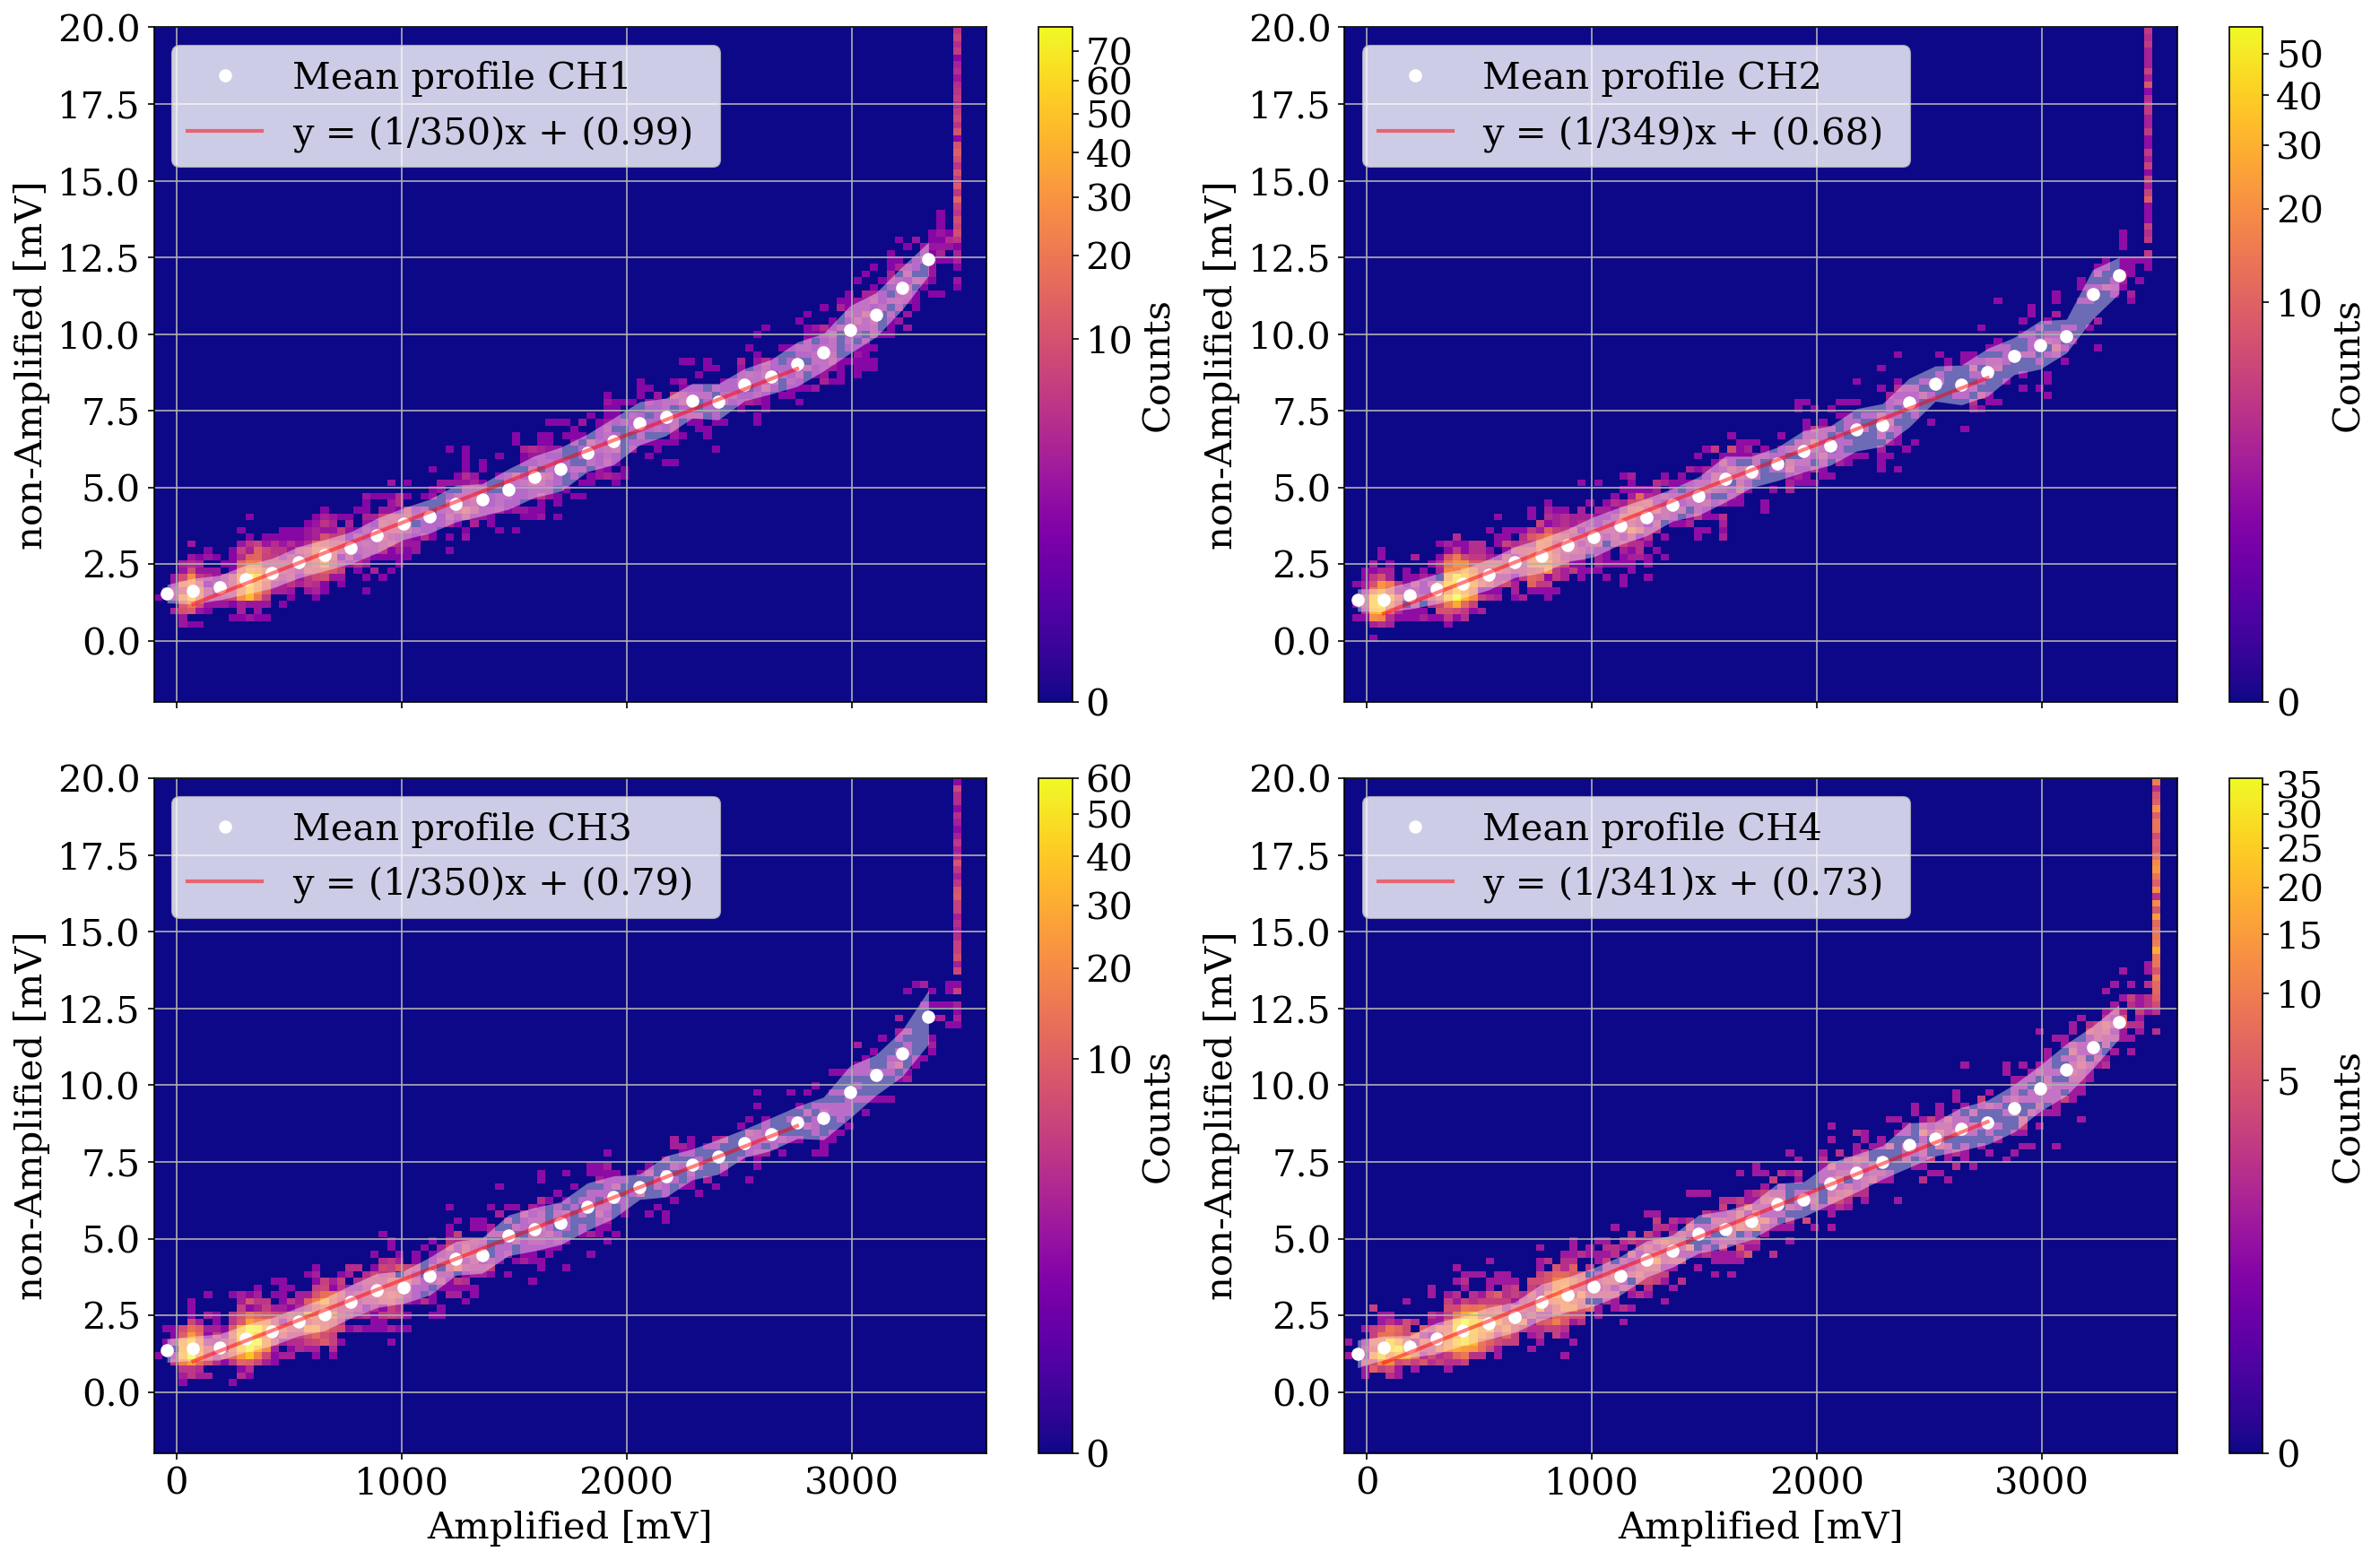

In [34]:
# Create subplots: 2 rows, 1 column

if len(Amp_channels) > 1:
    fig, axs = plt.subplots(len(Amp_channels)//2, 2, figsize=(18, len(Amp_channels)*3), dpi=150, sharex=True)
else:
    fig, ax = plt.subplots(1, 1, figsize=(16, 6), dpi=150, sharex=True)

# if len(Amp_channels) > 1:
#     fig.suptitle(f'{run}')
# else:
#     ax.set_title(f'{run}')

amp_factors = {}

time    = filtered_df['TIME'].values

if new_board:
    # yrange = (-20, 2)
    yrange = (-2, 20)
    xrange = (-100, 3600)
else:
    yrange = (0, 15)
    xrange = (0, 4000)
# Fit 
if new_board:
    # fit_range = (-7.5, 0)
    fit_range = (0, 2800)
else:
    # fit_range = (2.5, 10)
    fit_range = (1.3, 9)
    fit_range = (0, 2500)
    # fit_range = (-1e-9, 0.3e-8)

# Plot CHs
for i, ch in enumerate(Amp_channels):

    if len(Amp_channels) > 1:
        ax = (axs).flatten()[i]

    voltage_noAmp   = filtered_df[f'{noAmp_channels[i]}'].values
    voltage_Amp     = filtered_df[f'{Amp_channels[i]}'].values

    t_matrix        = time[time_window].reshape(nevents, -1)
    
    v_matrix_noAmp  = voltage_noAmp[time_window].reshape(nevents, -1)
    v_matrix_Amp    = voltage_Amp[time_window].reshape(nevents, -1)

    v_matrix_corrected_noAmp    = v_matrix_noAmp - fixBaselines_noAmp[f'CH{i+1}']
    v_matrix_corrected_Amp      = v_matrix_Amp - fixBaselines_Amp[f'CH{i+1}']

    if new_board:
        noAmp_amplitude   = v_matrix_corrected_noAmp.min(axis=1)  # (nevents,)
    else:
        noAmp_amplitude   = v_matrix_corrected_noAmp.max(axis=1)  # (nevents,)
    Amp_amplitude     = v_matrix_corrected_Amp.max(axis=1)  # (nevents,)

    # mask the data to include only that x-range
    # mask = (noAmp_amplitude >= x_min) & (noAmp_amplitude <= x_max)
    # mask = (noAmp_amplitude >= -np.inf) 
    y_vals = -noAmp_amplitude
    x_vals = Amp_amplitude


    # voltage_matrix = np.array([...]) # shape (nevents, nsamples)
    hist, _, _, img = ax.hist2d(x_vals, y_vals, bins=[100, 100], 
                                range=[xrange, yrange],
                                cmap='plasma', norm=mcolors.PowerNorm(gamma=0.3))

    fig.colorbar(img, ax=ax, label="Counts")

    # Mean profile
    bins = 30
    mean, xedges, _ = binned_statistic(x_vals, y_vals, statistic='mean', bins=bins, range=(xrange[0], 3400))
    std, _, _ = binned_statistic(x_vals, y_vals, statistic='std', bins=bins, range=(xrange[0], 3400))
    xcenters = 0.5 * (xedges[1:] + xedges[:-1])

    # Overlay mean ± std
    ax.plot(xcenters, mean, 'o', color='white', label=f'Mean profile CH{i+1}')
    ax.fill_between(xcenters, mean-std, mean+std, color='white', alpha=0.4, lw=0)

    # Fit line
    fit_mask = (xcenters > fit_range[0]) & (xcenters < fit_range[1]) & np.isfinite(mean)
  
    x       = xcenters[fit_mask]
    y       = mean[fit_mask]
    yerr    = std[fit_mask]

    params, cov = np.polyfit(x, y, 1, cov=True)
    m, b        = params

    # amp_factors[f'CH{i+1}'] = (m, b)
    amp_factors[f'CH{i+1}'] = (m, 0)
    # amp_factors[f'CH{i+1}'] = m

    x_fit = np.linspace(x.min(), x.max(), 200)
    y_fit = m * x_fit + b
    y_fit_var = (x_fit**2) * cov[0,0] + cov[1,1] + 2 * x_fit * cov[0,1]
    y_fit_err = np.sqrt(y_fit_var)

    ax.plot(x_fit, y_fit, 'red', lw=2, alpha = 0.5, label=f'y = (1/{1/m:.0f})x + ({b:.2f}) ')

    # # Plot fit confidence band (before fit line so line is on top)
    # ax.fill_between(x_fit, y_fit - y_fit_err, y_fit + y_fit_err,
    #                 color='red', alpha=0.3, label=f'Liner fit CI')
    


    # ax.set_ylabel(fr'non-Amplified [V$\cdot$s]')
    ax.set_ylabel(fr'non-Amplified [mV]')
    ax.grid(True)
    ax.legend(loc = 'upper left')

    # ax.set_xlim(x_min, x_max)
    # ax.set_ylim(0, 4000)

if len(all_channels) > 1:
    # axs[-1].set_xlabel(r'Amplified [V$\cdot$s]')
    axs[1][0].set_xlabel(r'Amplified [mV]')
    axs[1][1].set_xlabel(r'Amplified [mV]')
else:
    # ax.set_xlabel(r'Amplified [V$\cdot$s]')
    ax.set_xlabel(r'Amplified [mV]')

# Improve layout
plt.tight_layout()
plt.show()

In [35]:
Amp_amplitude.max()

3495.3082079798983

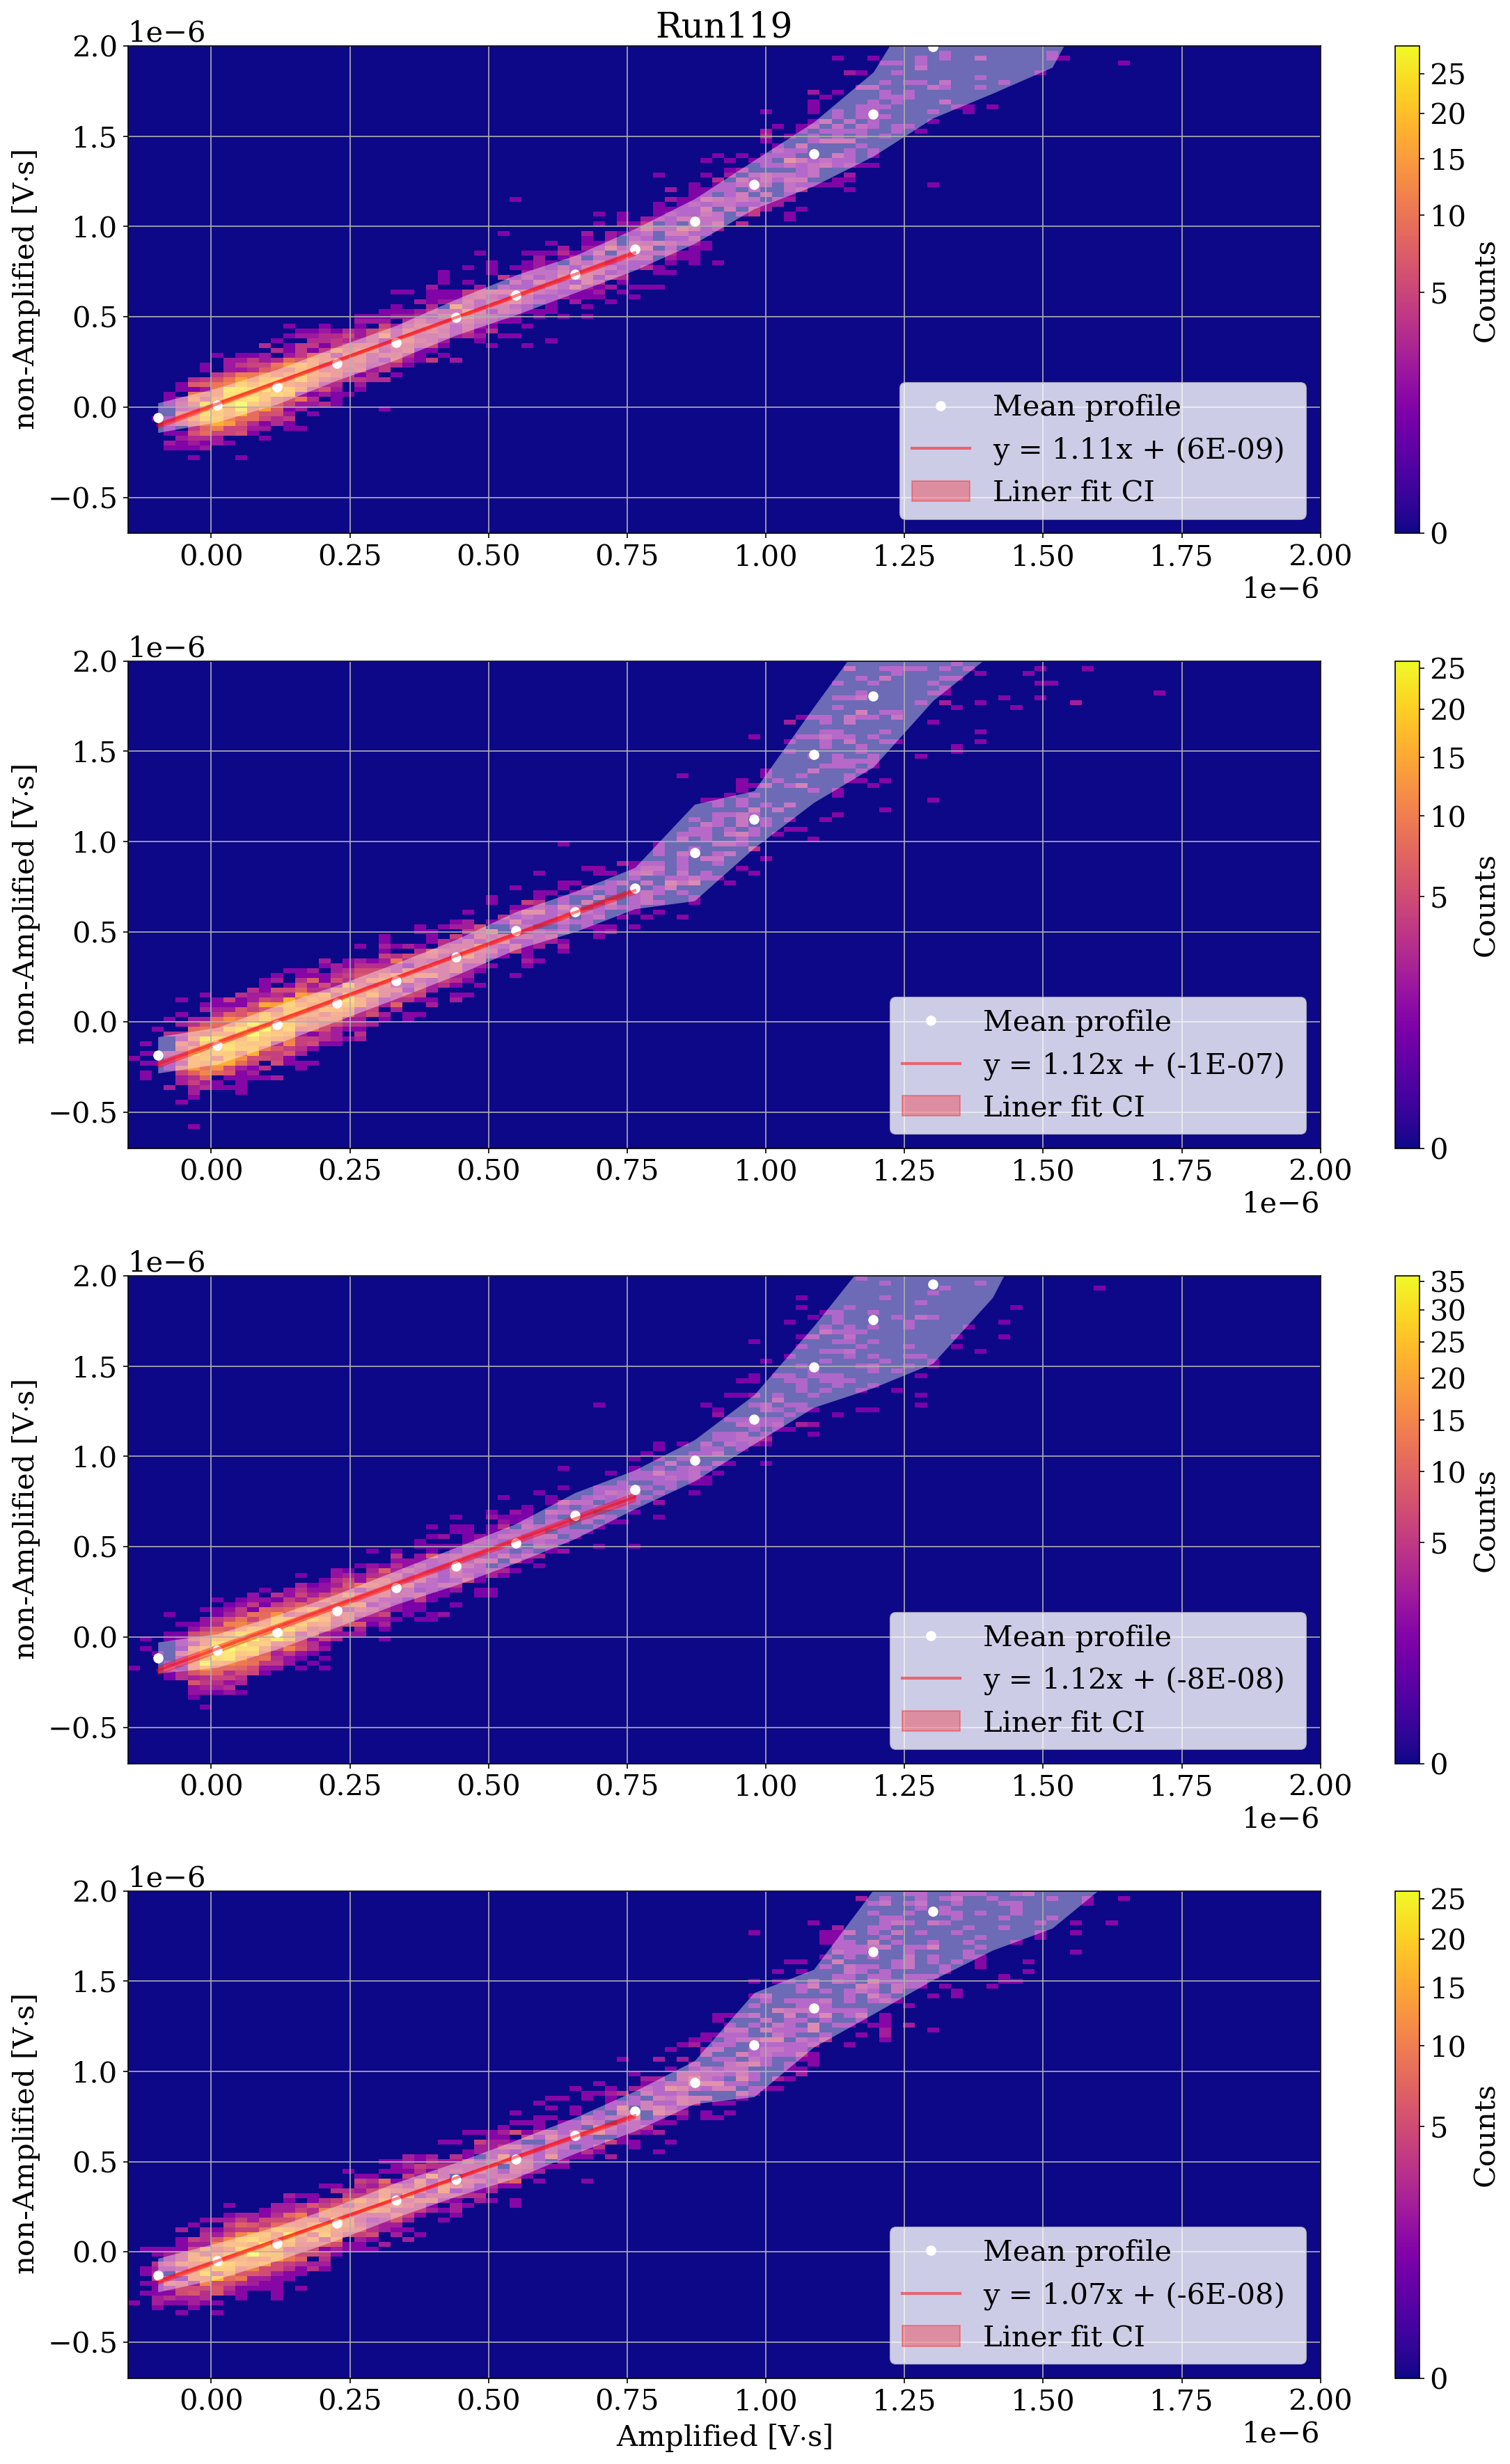

In [35]:
# Create subplots: 2 rows, 1 column

if len(Amp_channels) > 1:
    fig, axs = plt.subplots(len(Amp_channels), 1, figsize=(16, len(Amp_channels)*6), dpi=150, sharex=False)
else:
    fig, ax = plt.subplots(1, 1, figsize=(16, 6), dpi=150, sharex=True)

if len(Amp_channels) > 1:
    axs[0].set_title(f'{run}')
else:
    ax.set_title(f'{run}')

time    = filtered_df['TIME'].values

# define the range of x (noAmp_amplitude) to include

if new_board:
    yrange = (-7e-7, 2e-6)
    xrange = (-1.5e-7, 2e-6)
else:
    yrange = (-7e-7, 3e-6)
    xrange = (-1.5e-7, 2e-6)
# Fit 
if new_board:
    fit_range = (-5e-7, 8e-7)
else:
    # fit_range = (2.5, 10)
    # fit_range = (1.3, 9)
    fit_range = (-1e-7, 1.2e-6)
    # fit_range = (-np.inf, np.inf)

# Plot CHs
for i, ch in enumerate(Amp_channels):

    if len(Amp_channels) > 1:
        ax = axs[i]

    voltage_noAmp   = filtered_df[f'{noAmp_channels[i]}'].values
    voltage_Amp     = filtered_df[f'{Amp_channels[i]}'].values

    v_matrix_noAmp  = voltage_noAmp[time_window].reshape(nevents, -1)
    v_matrix_Amp    = voltage_Amp[time_window].reshape(nevents, -1)

    v_matrix_corrected_noAmp    = v_matrix_noAmp - fixBaselines_noAmp[f'CH{i+1}']
    v_matrix_corrected_Amp      = v_matrix_Amp - fixBaselines_Amp[f'CH{i+1}']

    m, b = amp_factors[f'CH{i+1}']

    # v_matrix_corr_noAmp_amplified = v_matrix_corrected_noAmp*m + b
    v_matrix_corr_noAmp_amplified = (v_matrix_corrected_noAmp - b)/m

    t_matrix        = time[time_window].reshape(nevents, -1)
    

    Amp_charge = np.trapz(v_matrix_corrected_Amp*1e-3,
                            x = t_matrix
                            ,axis = 1)

    noAmp_amplified_charge = np.trapz(v_matrix_corr_noAmp_amplified*1e-3,
                                        x = t_matrix
                                        ,axis = 1)
    

    # mask the data to include only that x-range
    # mask = (noAmp_amplified_charge >= x_min) & (noAmp_amplified_charge <= x_max)
    # mask = (noAmp_amplified_charge >= -np.inf) 
    y_vals = noAmp_amplified_charge
    x_vals = Amp_charge


    # voltage_matrix = np.array([...]) # shape (nevents, nsamples)
    hist, _, _, img = ax.hist2d(x_vals, y_vals, bins=[100, 100], 
                                range=[xrange, yrange],
                                cmap='plasma', norm=mcolors.PowerNorm(gamma=0.4))

    fig.colorbar(img, ax=ax, label="Counts")

    # Mean profile
    bins = 20
    mean, xedges, _ = binned_statistic(x_vals, y_vals, statistic='mean', bins=bins, range=xrange)
    std, _, _ = binned_statistic(x_vals, y_vals, statistic='std', bins=bins, range=xrange)
    xcenters = 0.5 * (xedges[1:] + xedges[:-1])

    # Overlay mean ± std
    ax.plot(xcenters, mean, 'o', color='white', label='Mean profile')
    ax.fill_between(xcenters, mean-std, mean+std, color='white', alpha=0.4, lw=0)

    # Fit line
    fit_mask = (xcenters > fit_range[0]) & (xcenters < fit_range[1]) & np.isfinite(mean)
  
    x       = xcenters[fit_mask]
    y       = mean[fit_mask]
    yerr    = std[fit_mask]


    params, cov = np.polyfit(x, y, 1, cov=True)
    m, b        = params

    x_fit = np.linspace(x.min(), x.max(), 200)
    y_fit = m * x_fit + b
    y_fit_var = (x_fit**2) * cov[0,0] + cov[1,1] + 2 * x_fit * cov[0,1]
    y_fit_err = np.sqrt(y_fit_var)

    ax.plot(x_fit, y_fit, 'red', lw=2, alpha = 0.5, label=f'y = {m:.2f}x + ({b:.0E}) ')

    # Plot fit confidence band (before fit line so line is on top)
    ax.fill_between(x_fit, y_fit - y_fit_err, y_fit + y_fit_err,
                    color='red', alpha=0.3, label=f'Liner fit CI')
    


    ax.set_ylabel(fr'non-Amplified [V$\cdot$s]')
    ax.grid(True)
    ax.legend(loc = 'lower right')

    # ax.set_xlim(x_vals.min(), 3e-6)
    # ax.set_ylim(0, 4000)

if len(all_channels) > 1:
    axs[-1].set_xlabel(r'Amplified [V$\cdot$s]')
else:
    ax.set_xlabel(r'Amplified [V$\cdot$s]')

# Improve layout
plt.tight_layout()
plt.show()

Found 12 events in the region


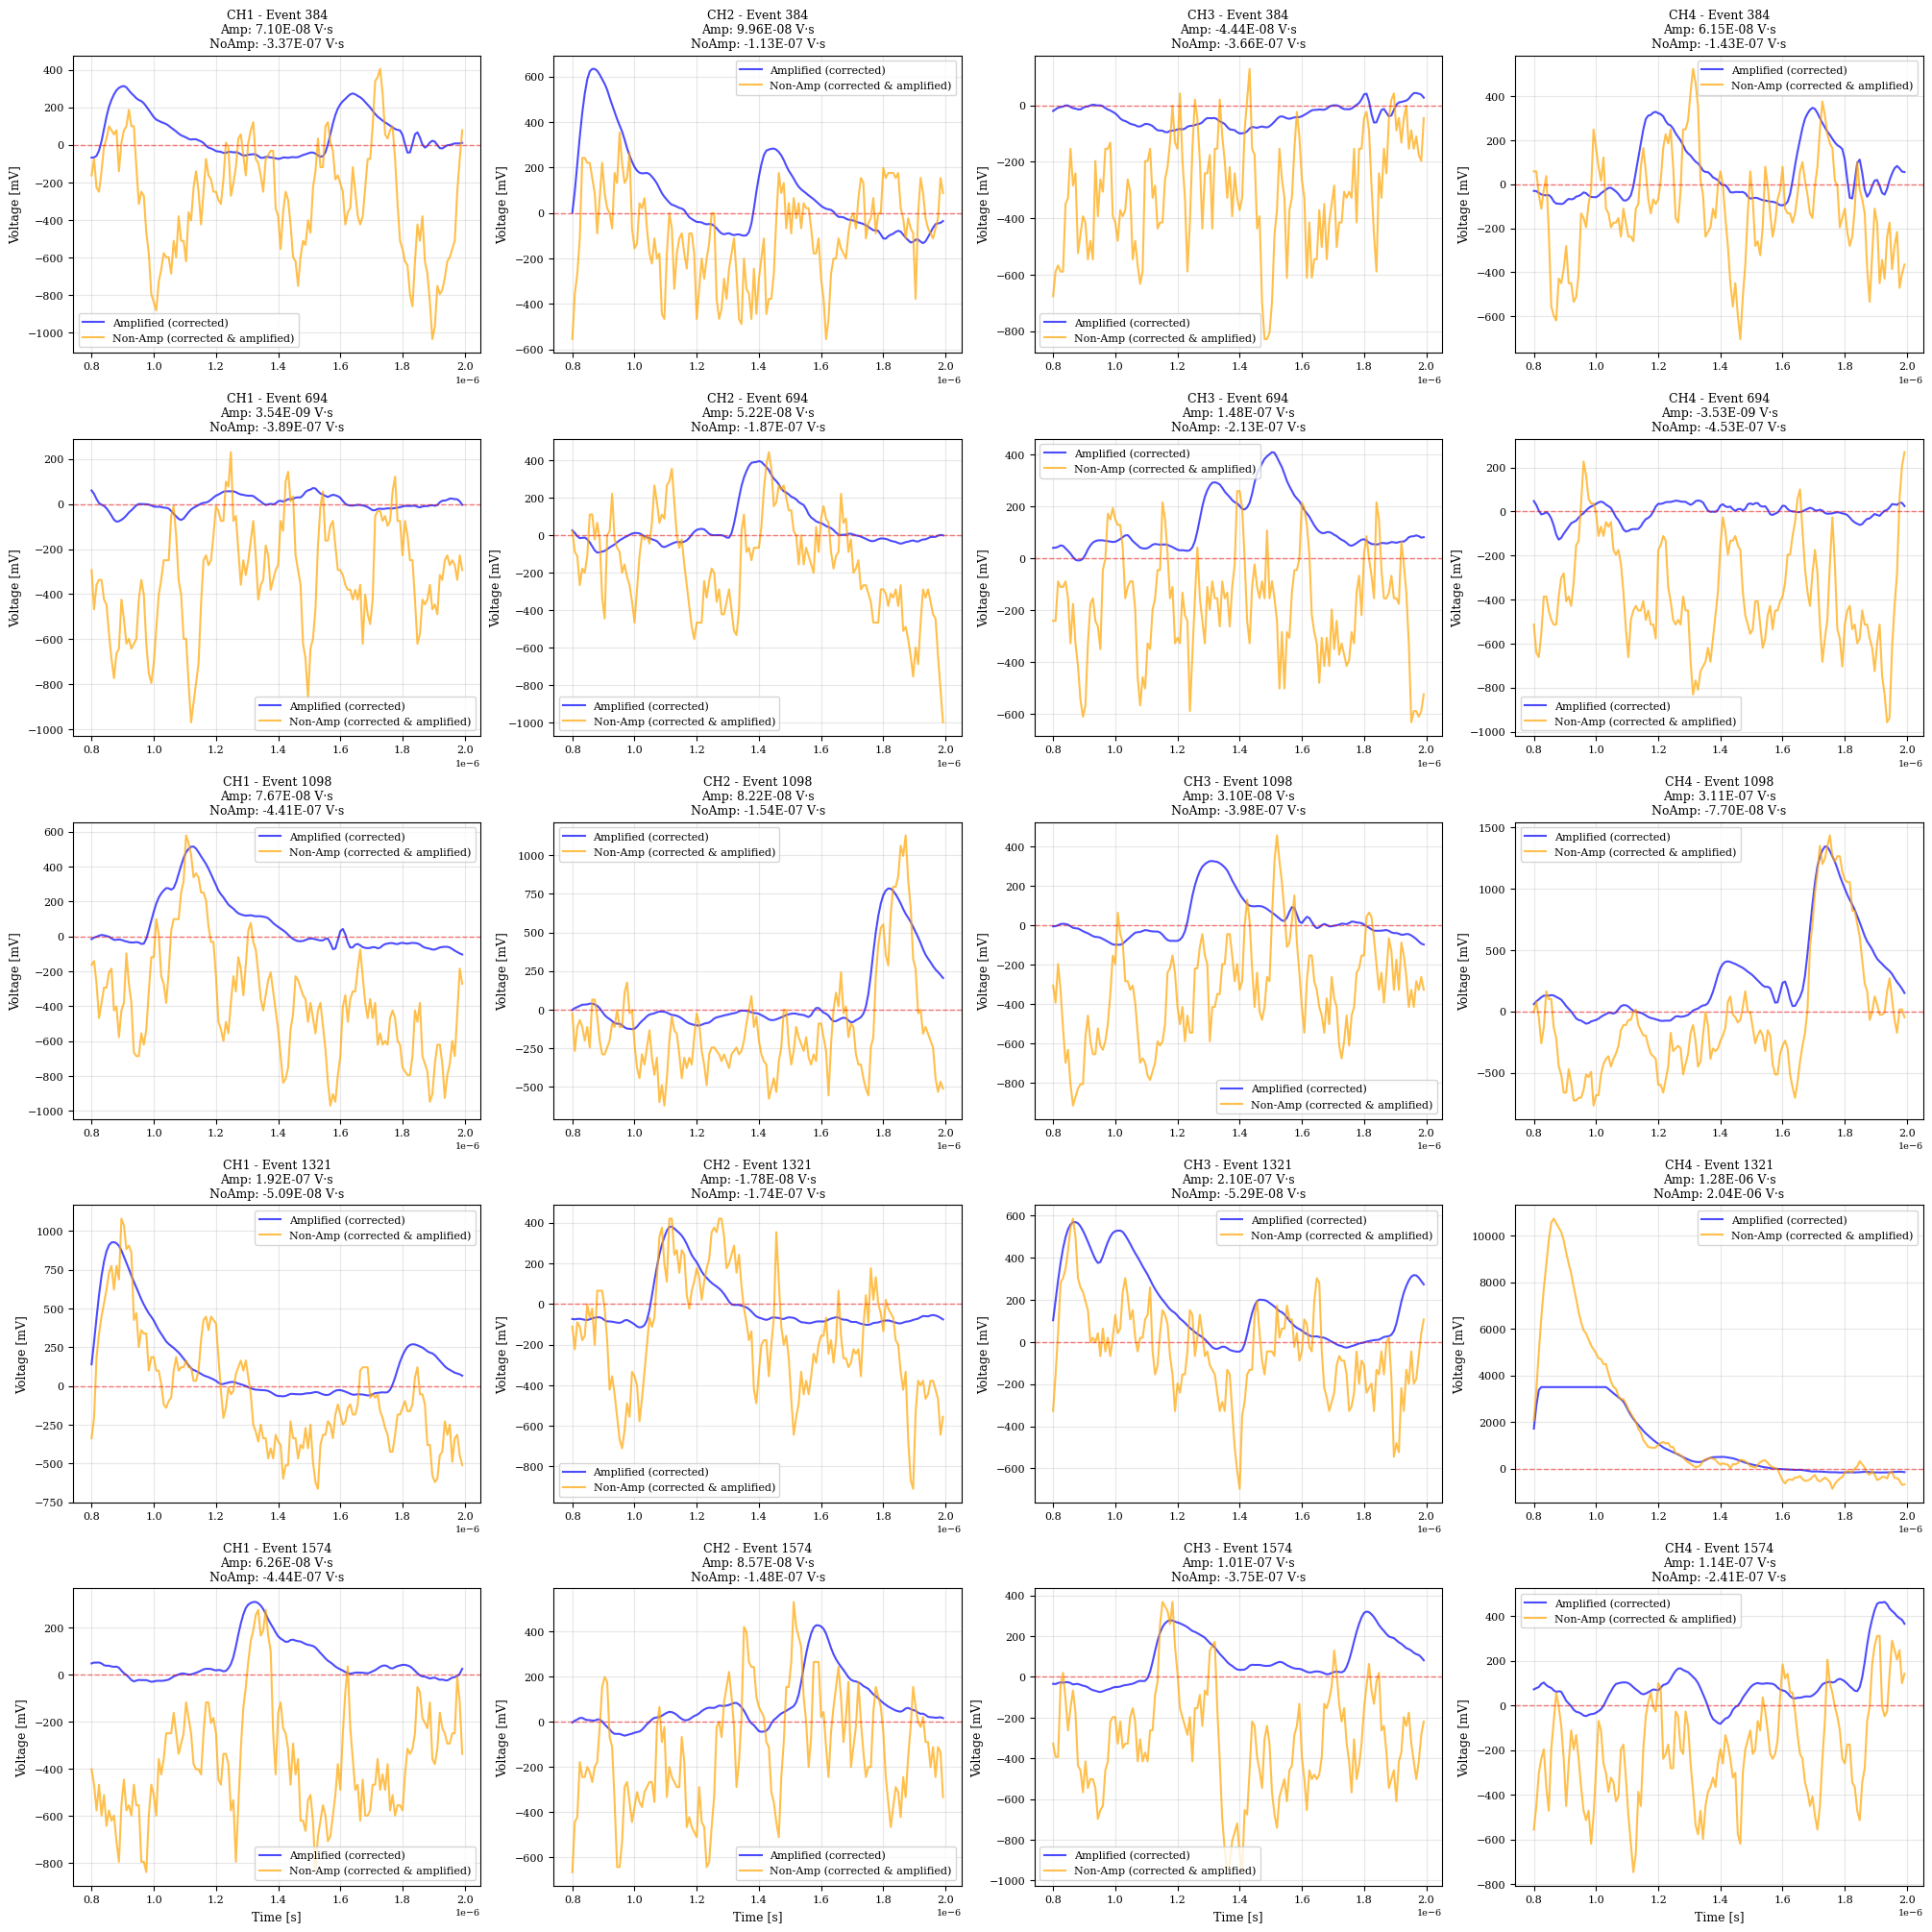


Statistics for events in region:

Channel 1:
  Amp charge mean: 1.24E-07 ± 1.61E-07
  NoAmp charge mean: -2.71E-07 ± 2.41E-07

Channel 2:
  Amp charge mean: 6.24E-08 ± 3.17E-08
  NoAmp charge mean: -1.69E-07 ± 2.45E-08

Channel 3:
  Amp charge mean: 4.23E-08 ± 8.95E-08
  NoAmp charge mean: -3.33E-07 ± 1.11E-07

Channel 4:
  Amp charge mean: 2.63E-07 ± 3.86E-07
  NoAmp charge mean: 8.18E-08 ± 6.64E-07


In [32]:
# Define the region to investigate
amp_charge_range = (-1e-7, 1e-7)  # Range around 0 for Amplified charge
noamp_charge_range = (-2e-7, 11e-7)  # Adjust based on your plot
# amp_charge_range = (5e-7, 7e-7)  # Range around 0 for Amplified charge
# noamp_charge_range = (0, 5e-7)  # Adjust based on your plot
# Get data for ALL channels
all_v_matrix_corrected_Amp = []
all_v_matrix_corr_noAmp_amplified = []
all_Amp_charge = []
all_noAmp_amplified_charge = []
all_t_matrix = []
for ch_idx in range(len(Amp_channels)):
    voltage_noAmp = filtered_df[f'{noAmp_channels[ch_idx]}'].values
    voltage_Amp = filtered_df[f'{Amp_channels[ch_idx]}'].values
    v_matrix_noAmp = voltage_noAmp[time_window].reshape(nevents, -1)
    v_matrix_Amp = voltage_Amp[time_window].reshape(nevents, -1)
    v_matrix_corrected_noAmp = v_matrix_noAmp - fixBaselines_noAmp[f'CH{ch_idx+1}']
    v_matrix_corrected_Amp = v_matrix_Amp - fixBaselines_Amp[f'CH{ch_idx+1}']
    m, b = amp_factors[f'CH{ch_idx+1}']
    v_matrix_corr_noAmp_amplified = (v_matrix_corrected_noAmp - b) / m
    t_matrix = time[time_window].reshape(nevents, -1)
    Amp_charge = np.trapz(v_matrix_corrected_Amp * 1e-3, x=t_matrix, axis=1)
    noAmp_amplified_charge = np.trapz(v_matrix_corr_noAmp_amplified * 1e-3, x=t_matrix, axis=1)
    all_v_matrix_corrected_Amp.append(v_matrix_corrected_Amp)
    all_v_matrix_corr_noAmp_amplified.append(v_matrix_corr_noAmp_amplified)
    all_Amp_charge.append(Amp_charge)
    all_noAmp_amplified_charge.append(noAmp_amplified_charge)
    all_t_matrix.append(t_matrix)
# Use channel 0 for finding events in the region (or change as needed)
ch_idx = 1
mask = ((all_Amp_charge[ch_idx] >= amp_charge_range[0]) & 
        (all_Amp_charge[ch_idx] <= amp_charge_range[1]) &
        (all_noAmp_amplified_charge[ch_idx] >= noamp_charge_range[0]) & 
        (all_noAmp_amplified_charge[ch_idx] <= noamp_charge_range[1]))
events_in_region = np.where(mask)[0]
print(f"Found {len(events_in_region)} events in the region")
# Plot up to 5 example waveforms
n_to_plot = min(5, len(events_in_region))
n_channels = len(Amp_channels)
fig, axs = plt.subplots(n_to_plot, n_channels, figsize=(5*n_channels, 4*n_to_plot), 
                        sharex=False, constrained_layout=True)
if n_to_plot == 1:
    axs = axs.reshape(1, -1)
for i, event_idx in enumerate(events_in_region[:n_to_plot]):
    for ch_idx in range(n_channels):
        ax = axs[i, ch_idx]
        # Plot both waveforms on the same axis
        ax.plot(all_t_matrix[ch_idx][event_idx], 
                all_v_matrix_corrected_Amp[ch_idx][event_idx],
                label='Amplified (corrected)', 
                color='blue', alpha=0.7)
        ax.plot(all_t_matrix[ch_idx][event_idx], 
                all_v_matrix_corr_noAmp_amplified[ch_idx][event_idx],
                label='Non-Amp (corrected & amplified)', 
                color='orange', alpha=0.7)
        ax.axhline(0, color='red', linestyle='--', alpha=0.5, linewidth=1)
        ax.set_ylabel('Voltage [mV]', fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8, loc='best')
        ax.tick_params(axis='both', which='major', labelsize=8)
        
        # Make the offset text (1e-6) smaller
        ax.ticklabel_format(style='scientific', axis='x', scilimits=(0,0))
        ax.xaxis.get_offset_text().set_fontsize(7)
        
        # Title with charge values
        title = f'CH{ch_idx+1} - Event {event_idx}\n'
        title += f'Amp: {all_Amp_charge[ch_idx][event_idx]:.2E} V·s\n'
        title += f'NoAmp: {all_noAmp_amplified_charge[ch_idx][event_idx]:.2E} V·s'
        ax.set_title(title, fontsize=9)
# Set x-labels for bottom row
for ch_idx in range(n_channels):
    axs[-1, ch_idx].set_xlabel('Time [s]', fontsize=9)
plt.show()
# Print statistics for all channels
print(f"\nStatistics for events in region:")
for ch_idx in range(n_channels):
    print(f"\nChannel {ch_idx+1}:")
    print(f"  Amp charge mean: {all_Amp_charge[ch_idx][mask].mean():.2E} ± {all_Amp_charge[ch_idx][mask].std():.2E}")
    print(f"  NoAmp charge mean: {all_noAmp_amplified_charge[ch_idx][mask].mean():.2E} ± {all_noAmp_amplified_charge[ch_idx][mask].std():.2E}")